# Discussion on Approximation Gaps in TAVIE-SSG: Section C of Supplementary Materials

## Jensen's Gap: Section C.1 of Supplementary Materials

### Tangent Minorizer Plot for Student's-$t$ Type I SSG Likelihood: Figure 2(a) of main manuscript (detailed version)

See `results_gaps/plots/student_t_tangent_plot.pdf`

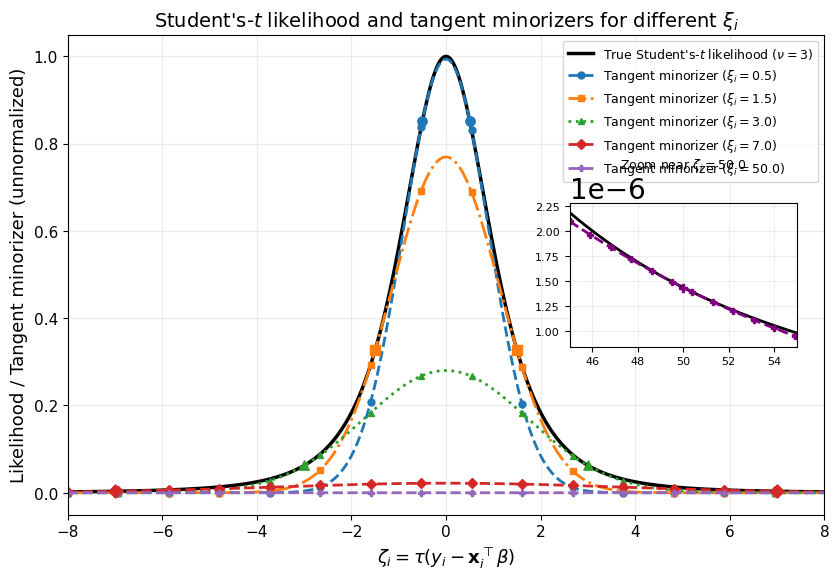

In [3]:
# required imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

nu = 3.0

def student_t_kernel(zeta, nu=3.0):
    return (1.0 + zeta**2 / nu) ** (-(nu + 1.0) / 2.0)

def h(t, nu=3.0):
    return -0.5 * (nu + 1.0) * np.log(1.0 + t / nu)

def A(xi, nu=3.0):
    return -(nu + 1.0) / (2.0 * (nu + xi**2))

def gamma(xi, nu=3.0):
    return h(xi**2, nu=nu) - xi**2 * A(xi, nu=nu)

def tangent_minorizer(zeta, xi, nu=3.0):
    return np.exp(A(xi, nu=nu) * zeta**2 + gamma(xi, nu=nu))

# ------------------------------------------------------------
# Main plot range
# ------------------------------------------------------------
zeta = np.linspace(-8, 8, 1200)
xi_values = [0.5, 1.5, 3.0, 7.0, 50.0]

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
linestyles = ["--", "-.", ":", "--", "--"]
markers = ["o", "s", "^", "D", "P"]

fig, ax = plt.subplots(figsize=(8.8, 6.0))

# True likelihood
ax.plot(
    zeta,
    student_t_kernel(zeta, nu=nu),
    color="black",
    linewidth=2.5,
    label=r"True Student's-$t$ likelihood ($\nu=3$)"
)

# Tangent minorizers on main plot
for xi, c, ls, mk in zip(xi_values, colors, linestyles, markers):
    phi_vals = tangent_minorizer(zeta, xi, nu=nu)
    ax.plot(
        zeta,
        phi_vals,
        color=c,
        linestyle=ls,
        linewidth=2.0,
        marker=mk,
        markevery=80,
        markersize=5,
        label=rf"Tangent minorizer ($\xi_i={xi}$)"
    )
    y_tan = student_t_kernel(np.array([xi]), nu=nu)[0]
    ax.scatter([xi, -xi], [y_tan, y_tan], color=c, marker=mk, s=45, zorder=5)

ax.set_xlabel(r"$\zeta_i = \tau(y_i - \mathbf{x}_i^{\top}\beta)$", fontsize=13)
ax.set_ylabel("Likelihood / Tangent minorizer (unnormalized)", fontsize=13)
ax.set_title(r"Student's-$t$ likelihood and tangent minorizers for different $\xi_i$", fontsize=14)
ax.set_xlim(-8, 8)
ax.set_ylim(bottom=-0.05)
ax.grid(alpha=0.25)
ax.legend(frameon=True, fontsize=9, loc="upper right")
ax.tick_params(labelsize=11)

# ------------------------------------------------------------
# Inset zoom around zeta_i = 50 with tangent minorizer at xi_i = 50
# ------------------------------------------------------------
xi_zoom = 50.0
zeta_zoom = np.linspace(45, 55, 500)

true_zoom = student_t_kernel(zeta_zoom, nu=nu)
phi_zoom = tangent_minorizer(zeta_zoom, xi_zoom, nu=nu)
y_zoom_tan = student_t_kernel(np.array([xi_zoom]), nu=nu)[0]

axins = inset_axes(ax, width="30%", height="30%", loc="center right", borderpad=1.0)

axins.plot(
    zeta_zoom,
    true_zoom,
    color="black",
    linewidth=2.0
)
axins.plot(
    zeta_zoom,
    phi_zoom,
    color="purple",
    linestyle="--",
    linewidth=2.0,
    marker="P",
    markevery=45,
    markersize=4
)
axins.scatter([xi_zoom], [y_zoom_tan], color="purple", marker="P", s=35, zorder=5)

axins.set_title(r"Zoom near $\zeta_i=50.0$", fontsize=9)
axins.set_xlim(45, 55)

# keep zoomed y-limits tight around the tiny tail values
ymin = min(true_zoom.min(), phi_zoom.min())
ymax = max(true_zoom.max(), phi_zoom.max())
pad = 0.08 * (ymax - ymin) if ymax > ymin else 1e-8
axins.set_ylim(ymin - pad, ymax + pad)

axins.grid(alpha=0.2)
axins.tick_params(labelsize=8)

plt.subplots_adjust(left=0.11, right=0.97, top=0.92, bottom=0.12)
fig.savefig("results_gaps/plots/student_t_tangent_plot.pdf", dpi=300, bbox_inches="tight")

### Tangent Minorizer Plot for Negative-Binomial Type II SSG Likelihood: Figure 2c of main manuscript (detailed version)

See `results_gaps/plots/nb_tangent_plot.pdf`

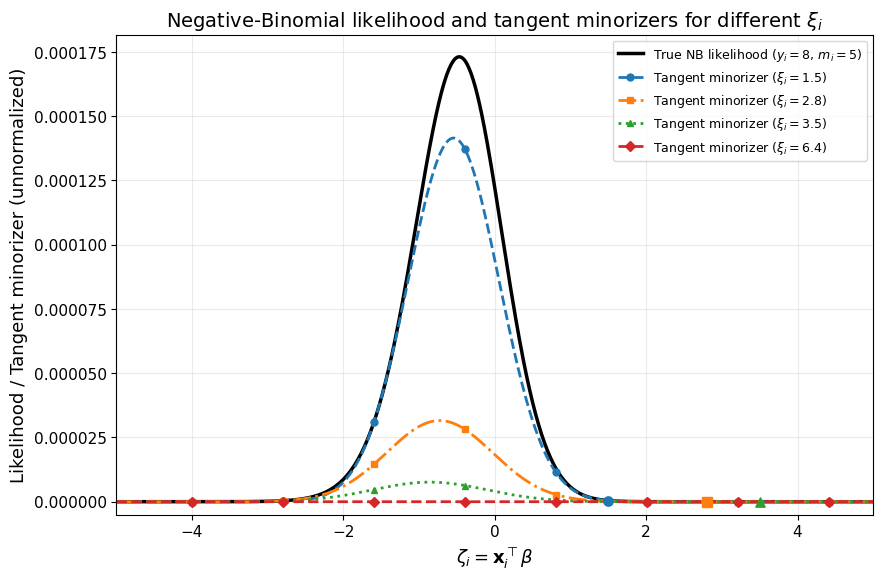

In [4]:
# required imports
import numpy as np
import matplotlib.pyplot as plt

y_i = 8.0
m_i = 5.0

def nb_kernel(zeta, y, m):
    """Unnormalized Negative-Binomial likelihood kernel as a function of zeta."""
    return np.exp(m * zeta) / (1.0 + np.exp(zeta)) ** (y + m)

def A(xi):
    """A(xi) = h'(xi^2) for Type II SSG likelihood."""
    xi = np.asarray(xi, dtype=float)
    out = np.empty_like(xi)
    mask0 = np.isclose(xi, 0.0)
    out[mask0] = -1.0 / 8.0
    out[~mask0] = -np.tanh(xi[~mask0] / 2.0) / (4.0 * xi[~mask0])
    return out if out.ndim > 0 else float(out)

def h_from_xi(xi):
    """h(xi^2) written directly in terms of xi >= 0."""
    return -np.log(2.0 * np.cosh(xi / 2.0))

def gamma(xi):
    """gamma(xi) = h(xi^2) - xi^2 A(xi)."""
    return h_from_xi(xi) - xi**2 * A(np.array([xi]))[0]

def tangent_minorizer(zeta, xi, y, m):
    """Unnormalized tangent minorizer phi(zeta | xi)."""
    coeff_linear = 0.5 * (m - y)
    coeff_quad = (y + m) * A(np.array([xi]))[0]
    const_term = (y + m) * gamma(xi)
    return np.exp(coeff_linear * zeta + coeff_quad * zeta**2 + const_term)

# Grid for zeta_i = x_i^T beta
zeta = np.linspace(-10, 10, 1500)

# Different tangency points xi_i
xi_values = [1.5, 2.8, 3.5, 6.4]

# Plot styles
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
linestyles = ["--", "-.", ":", "--"]
markers = ["o", "s", "^", "D"]

fig, ax = plt.subplots(figsize=(8.8, 6.0))

# True NB likelihood: solid black
ax.plot(
    zeta,
    nb_kernel(zeta, y_i, m_i),
    color="black",
    linewidth=2.5,
    label=rf"True NB likelihood ($y_i={int(y_i)},\, m_i={int(m_i)}$)"
)

# Tangent minorizers
for xi, c, ls, mk in zip(xi_values, colors, linestyles, markers):
    phi_vals = tangent_minorizer(zeta, xi, y_i, m_i)

    ax.plot(
        zeta,
        phi_vals,
        color=c,
        linestyle=ls,
        linewidth=2.0,
        marker=mk,
        markevery=90,
        markersize=5,
        label=rf"Tangent minorizer ($\xi_i={xi}$)"
    )

    # Mark the tangency points at ±xi
    # Since the likelihood is not symmetric in zeta here, the tangency is at +xi
    y_tan = nb_kernel(np.array([xi]), y_i, m_i)[0]
    ax.scatter([xi], [y_tan], color=c, marker=mk, s=45, zorder=5)

ax.set_xlabel(r"$\zeta_i = \mathbf{x}_i^{\top}\beta$", fontsize=13)
ax.set_ylabel("Likelihood / Tangent minorizer (unnormalized)", fontsize=13)
ax.set_title(r"Negative-Binomial likelihood and tangent minorizers for different $\xi_i$", fontsize=14)
ax.set_xlim(-5, 5)
ax.set_ylim(bottom=-0.000005)
ax.grid(alpha=0.25)
ax.legend(frameon=True, fontsize=9, loc="upper right")
ax.tick_params(labelsize=11)

plt.subplots_adjust(left=0.11, right=0.97, top=0.92, bottom=0.12)

# Save if needed
fig.savefig("results_gaps/plots/nb_tangent_plot.pdf", dpi=300, bbox_inches="tight")

plt.show()

### Jensen's gap at optimized value for Student's-$t$ Type I SSG Likelihood: Figure 2b of main manuscript and Figure 2 of Supplementary Materials (left panel)

See `results_gaps/plots/student_t_jensen_gap_xi1star_zeta1star.pdf`

╭─ TAVIE Fit for student ─╮
│  Starting TAVIE fit!    │
╰─────────────────────────╯

Converged in 41 iterations.
xi_1_star   = 1.2828470581883802
zeta_1_star = 1.2710784806942086


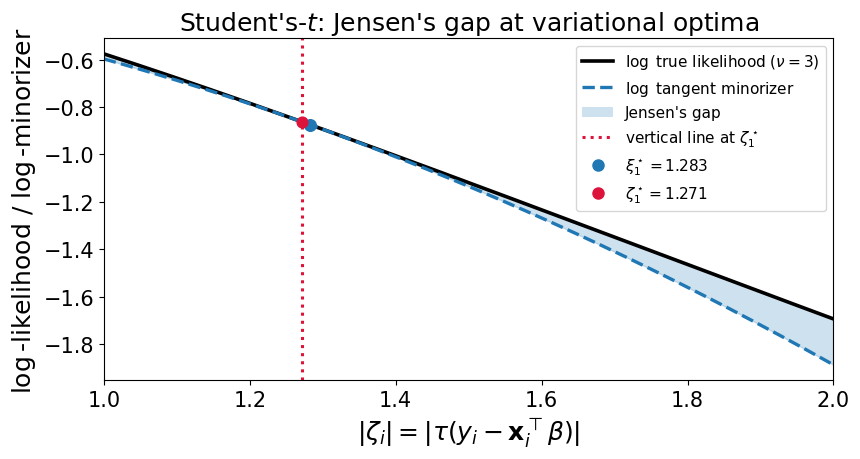

In [5]:
# required imports
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from TAVIE import *

# ============================================================
# Student's-t log-kernel and tangent minorizer
# ============================================================

def h(t, nu=3.0):
    return -0.5 * (nu + 1.0) * np.log(1.0 + t / nu)

def A(xi, nu=3.0):
    return -(nu + 1.0) / (2.0 * (nu + xi**2))

def gamma(xi, nu=3.0):
    return h(xi**2, nu=nu) - xi**2 * A(xi, nu=nu)

def log_student_t_kernel(zeta, nu=3.0):
    return -0.5 * (nu + 1.0) * np.log(1.0 + zeta**2 / nu)

def log_tangent_minorizer(zeta, xi, nu=3.0):
    return A(xi, nu=nu) * zeta**2 + gamma(xi, nu=nu)

# ============================================================
# Simulated data
# ============================================================

n = 500
total_p = 9  # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 8
tau2 = 3
df = 3

np.random.seed(123)

X = np.random.normal(size=(n, p))
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p + 1)
error = np.random.standard_t(df=df, size=n) / np.sqrt(tau2)
y = beta_true[0] + X @ beta_true[1:] + error

# ============================================================
# Fit TAVIE model
# ============================================================

student_model = TAVIE_loc_scale(family="student", fit_intercept=True)
student_model.fit(X, y, nu=df, verbose=True)

xi_1_star = float(student_model.fitted_values['xi'][0])

beta_star, tau2_star = student_model.get_TAVIE_means()
res = y - (beta_star[0] + X @ beta_star[1:])
zeta_1_star = float(np.abs(np.sqrt(tau2_star) * res[0]))

print("xi_1_star   =", xi_1_star)
print("zeta_1_star =", zeta_1_star)

# ============================================================
# Plot settings: choose your own x-limits here
# ============================================================

xleft = 1.0
xright = 2.0  

zeta = np.linspace(xleft, xright, 1500)

log_true = log_student_t_kernel(zeta, nu=df)
log_phi = log_tangent_minorizer(zeta, xi_1_star, nu=df)

# Tangency point
y_tan = log_student_t_kernel(np.array([xi_1_star]), nu=df)[0]

# zeta_1_star location on true curve
y_zeta = log_student_t_kernel(np.array([zeta_1_star]), nu=df)[0]

# ============================================================
# Create plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

# True log-likelihood
ax.plot(
    zeta,
    log_true,
    color="black",
    linewidth=2.6
)

# Tangent minorizer at xi_1_star
ax.plot(
    zeta,
    log_phi,
    color="tab:blue",
    linestyle="--",
    linewidth=2.4
)

# Shade Jensen gap
ax.fill_between(
    zeta,
    log_phi,
    log_true,
    where=(log_true >= log_phi),
    color="tab:blue",
    alpha=0.22,
    interpolate=True
)

# Tangency point at xi_1_star
ax.scatter(
    [xi_1_star],
    [y_tan],
    color="tab:blue",
    s=70,
    zorder=5
)

# Vertical dotted line at zeta_1_star
ax.axvline(
    x=zeta_1_star,
    color="crimson",
    linestyle=":",
    linewidth=2.2
)

# Marker on the true curve at zeta_1_star
ax.scatter(
    [zeta_1_star],
    [y_zeta],
    color="crimson",
    s=60,
    zorder=6
)

# Optional annotations on plot
# ax.annotate(
#     rf"$\xi_1^\star={xi_1_star:.3f}$",
#     xy=(xi_1_star, y_tan),
#     xytext=(xi_1_star + 0.15, y_tan + 0.12),
#     fontsize=12,
#     color="tab:blue"
# )

# ax.annotate(
#     rf"$\zeta_1^\star={zeta_1_star:.3f}$",
#     xy=(zeta_1_star, y_zeta),
#     xytext=(zeta_1_star + 0.15, y_zeta - 0.30),
#     fontsize=12,
#     color="crimson"
# )

# Labels and title
ax.set_xlabel(r"$|\zeta_i| = |\tau(y_i-\mathbf{x}_i^\top\beta)|$", fontsize=18)
ax.set_ylabel(r"$\log$-likelihood / $\log$-minorizer", fontsize=18)
ax.set_title(
    r"Student's-$t$: Jensen's gap at variational optima",
    fontsize=18
)

ax.tick_params(labelsize=15)
ax.set_xlim(xleft, xright)

# ============================================================
# Custom legend with xi_1_star and zeta_1_star explicitly shown
# ============================================================

legend_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=2.6,
        label=rf"$\log$ true likelihood $(\nu={df})$"
    ),
    Line2D(
        [0], [0],
        color="tab:blue",
        lw=2.4,
        ls="--",
        label=r"$\log$ tangent minorizer"
    ),
    Patch(
        facecolor="tab:blue",
        alpha=0.22,
        edgecolor="none",
        label=r"Jensen's gap"
    ),
    Line2D(
        [0], [0],
        color="crimson",
        lw=2.2,
        ls=":",
        label=r"vertical line at $\zeta_1^\star$"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="tab:blue",
        linestyle="None",
        markersize=8,
        label=rf"$\xi_1^\star = {xi_1_star:.3f}$"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="crimson",
        linestyle="None",
        markersize=8,
        label=rf"$\zeta_1^\star = {zeta_1_star:.3f}$"
    )
]

ax.legend(handles=legend_handles, loc="best", fontsize=11, frameon=True)

plt.tight_layout()

fig.savefig(
    "results_gaps/plots/student_t_jensen_gap_xi1star_zeta1star.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Jensen's gap at optimized value for Negative-Binomial Type II SSG Likelihood: Figure 2d of main manuscript and Figure 2 of Supplementary Materials (right panel)

See `results_gaps/plots/negbin_jensen_gap_xi1star_zeta1star.pdf`

╭─ TAVIE Fit for negbin ─╮
│  Starting TAVIE fit!   │
╰────────────────────────╯

Converged in 60 iterations.
xi_1_star   = 3.755348537768828
zeta_1_star = 3.749143992653644
y_1         = 0
m_1         = 10


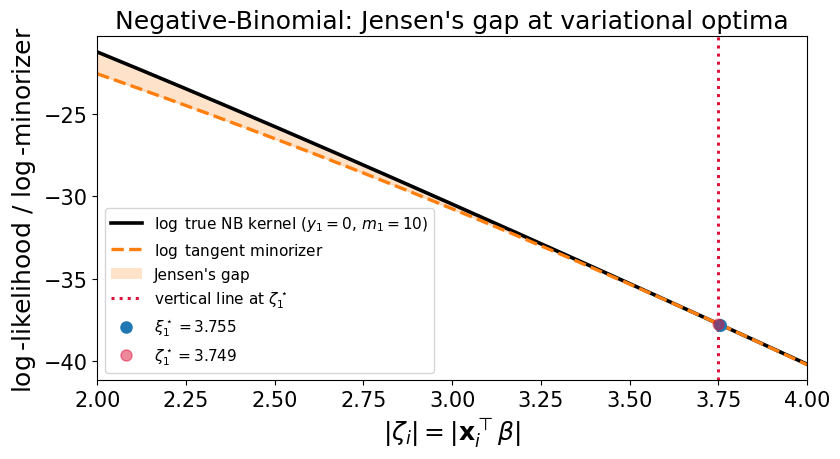

In [6]:
# required imports
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from TAVIE import *

# ============================================================
# Negative-Binomial Type II log-kernel and tangent minorizer
# ============================================================

def h_nb(t):
    return -np.log(2.0 * np.cosh(np.sqrt(t) / 2.0))

def A_nb(xi):
    xi = np.asarray(xi, dtype=float)
    out = np.empty_like(xi)

    small = np.isclose(xi, 0.0)
    out[small] = -1.0 / 8.0                      # limit as xi -> 0
    out[~small] = -np.tanh(xi[~small] / 2.0) / (4.0 * xi[~small])

    return out if out.ndim > 0 else float(out)

def gamma_nb(xi):
    return h_nb(xi**2) - xi**2 * A_nb(xi)

def log_negbin_kernel(zeta, y_i, m_i):
    # up to an additive constant independent of zeta
    return 0.5 * (y_i - m_i) * zeta + (y_i + m_i) * h_nb(zeta**2)

def log_negbin_tangent_minorizer(zeta, xi, y_i, m_i):
    return (
        0.5 * (y_i - m_i) * zeta
        + (y_i + m_i) * (A_nb(xi) * zeta**2 + gamma_nb(xi))
    )

# ============================================================
# Simulated Negative-Binomial data
# ============================================================

n = 200
total_p = 9  # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 8
m = 10                 # dispersion / size parameter
np.random.seed(123)

X = np.random.normal(size=(n, p))
beta_true = np.random.normal(loc=0.0, scale=0.5, size=p + 1)

eta_true = beta_true[0] + X @ beta_true[1:]
mu_true = np.exp(eta_true)

# NumPy parameterization:
# Y ~ NB(size=m, prob=m/(m+mu))  => E[Y]=mu
prob = m / (m + mu_true)
y = np.random.negative_binomial(n=m, p=prob, size=n)

# ============================================================
# Fit TAVIE Negative-Binomial model
# ============================================================

nb_model = TAVIE_type_II(family="negbin", fit_intercept=True)

# If your implementation uses a different argument name than m,
# replace m=m below by the correct one (for example, size=m).
nb_model.fit(X, y, r=m, verbose=True)

xi_1_star = float(nb_model.fitted_values['xi'][0])

beta_star = nb_model.get_TAVIE_means()
eta_star = beta_star[0] + X @ beta_star[1:]
zeta_1_star = float(eta_star[0])

y_1 = int(y[0])
m_1 = m

print("xi_1_star   =", xi_1_star)
print("zeta_1_star =", zeta_1_star)
print("y_1         =", y_1)
print("m_1         =", m_1)

# ============================================================
# Plot settings: choose your own x-limits here
# ============================================================

xleft = 2.0
xright = 4.0

zeta = np.linspace(xleft, xright, 2000)

log_true = log_negbin_kernel(zeta, y_i=y_1, m_i=m_1)
log_phi = log_negbin_tangent_minorizer(zeta, xi=xi_1_star, y_i=y_1, m_i=m_1)

# Values at xi_1_star and zeta_1_star
y_tan = log_negbin_kernel(np.array([xi_1_star]), y_i=y_1, m_i=m_1)[0]
y_zeta = log_negbin_kernel(np.array([zeta_1_star]), y_i=y_1, m_i=m_1)[0]

# ============================================================
# Create plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

# True log-kernel
ax.plot(
    zeta,
    log_true,
    color="black",
    linewidth=2.6
)

# Tangent minorizer at xi_1_star
ax.plot(
    zeta,
    log_phi,
    color="tab:orange",
    linestyle="--",
    linewidth=2.4
)

# Shade Jensen gap
ax.fill_between(
    zeta,
    log_phi,
    log_true,
    where=(log_true >= log_phi),
    color="tab:orange",
    alpha=0.22,
    interpolate=True
)

# Tangency point at xi_1_star
ax.scatter(
    [xi_1_star],
    [y_tan],
    color="tab:blue",
    s=70,
    zorder=5
)

# Vertical dotted line at zeta_1_star
ax.axvline(
    x=zeta_1_star,
    color="crimson",
    linestyle=":",
    linewidth=2.2
)

# Marker on true curve at zeta_1_star
ax.scatter(
    [zeta_1_star],
    [y_zeta],
    color="crimson",
    s=60,
    zorder=6,
    alpha=0.5
)

# Labels and title
ax.set_xlabel(r"$|\zeta_i| = |\mathbf{x}_i^\top\beta|$", fontsize=18)
ax.set_ylabel(r"$\log$-likelihood / $\log$-minorizer", fontsize=18)
ax.set_title(
    r"Negative-Binomial: Jensen's gap at variational optima",
    fontsize=18
)

ax.tick_params(labelsize=15)
ax.set_xlim(xleft, xright)

# ============================================================
# Custom legend
# ============================================================

legend_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=2.6,
        label=rf"$\log$ true NB kernel $(y_1={y_1},\,m_1={m_1})$"
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        lw=2.4,
        ls="--",
        label=r"$\log$ tangent minorizer"
    ),
    Patch(
        facecolor="tab:orange",
        alpha=0.22,
        edgecolor="none",
        label=r"Jensen's gap"
    ),
    Line2D(
        [0], [0],
        color="crimson",
        lw=2.2,
        ls=":",
        label=r"vertical line at $\zeta_1^\star$"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="tab:blue",
        linestyle="None",
        markersize=8,
        label=rf"$\xi_1^\star = {xi_1_star:.3f}$"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="crimson",
        linestyle="None",
        alpha=0.5,
        markersize=8,
        label=rf"$\zeta_1^\star = {zeta_1_star:.3f}$"
    )
]

ax.legend(handles=legend_handles, loc="best", fontsize=11, frameon=True)

plt.tight_layout()

fig.savefig(
    "results_gaps/plots/negbin_jensen_gap_xi1star_zeta1star.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Jensen's gap at different $\xi_i$ for Student's-$t$ Type I SSG Likelihood: Figure 1 of Supplementary Materials (left panel)

See `results_gaps/plots/student_t_jensen_gap_highlighted.pdf`

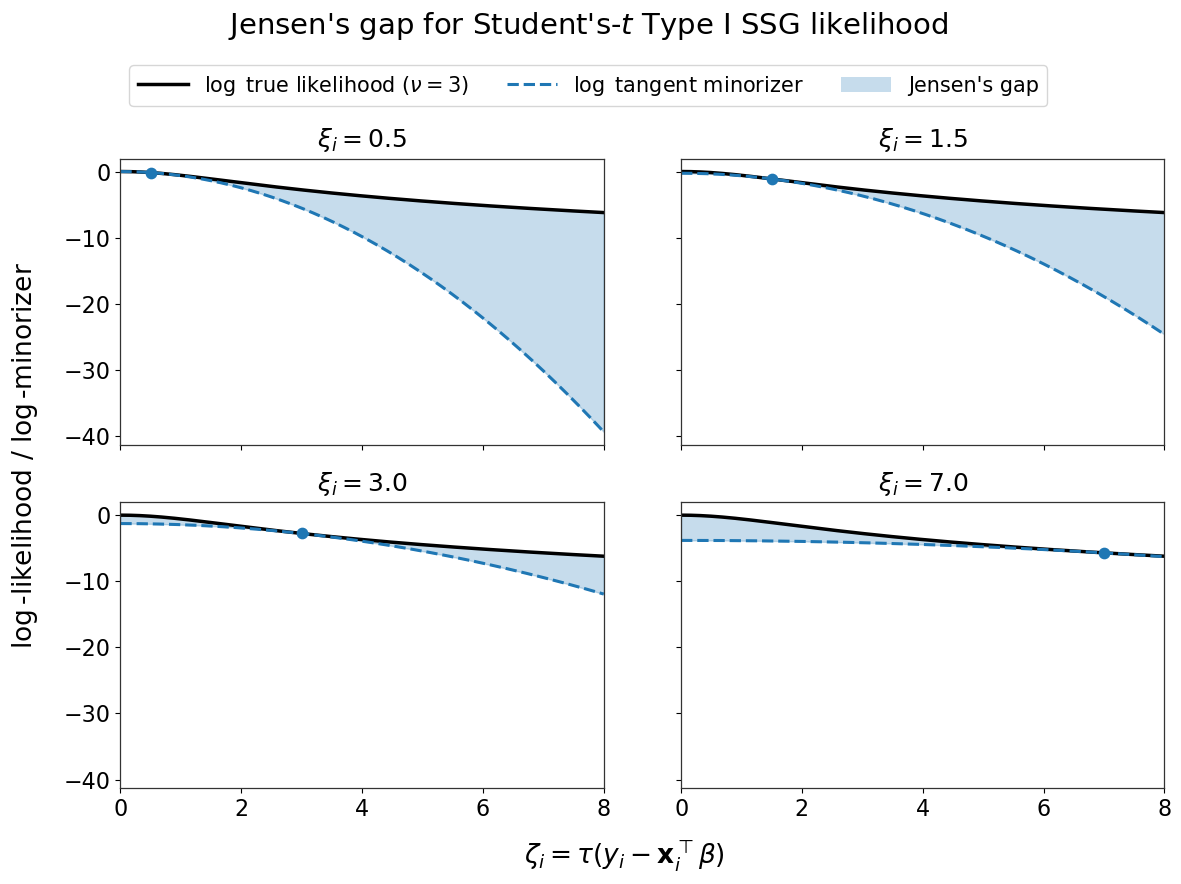

In [7]:
# ============================================================
# REQUIRED IMPORTS
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# FUNCTIONS
# ============================================================

nu = 3.0
xlim = 8.0


def h(t, nu=3.0):
    return -0.5 * (nu + 1.0) * np.log(1.0 + t / nu)


def A(xi, nu=3.0):
    return -(nu + 1.0) / (2.0 * (nu + xi**2))


def gamma(xi, nu=3.0):
    return h(xi**2, nu=nu) - xi**2 * A(xi, nu=nu)


def log_student_t_kernel(zeta, nu=3.0):
    return -0.5 * (nu + 1.0) * np.log(
        1.0 + zeta**2 / nu
    )


def log_tangent_minorizer(zeta, xi, nu=3.0):
    return (
        A(xi, nu=nu) * zeta**2
        + gamma(xi, nu=nu)
    )


# ============================================================
# SETTINGS
# ============================================================

zeta = np.linspace(0.0, xlim, 1200)

xi_values = [0.5, 1.5, 3.0, 7.0]

colors = [
    "tab:blue",
    "tab:blue",
    "tab:blue",
    "tab:blue",
]

linestyles = [
    "--",
    "--",
    "--",
    "--",
]

markers = [
    "o",
    "o",
    "o",
    "o",
]


# ============================================================
# CREATE 2 x 2 PANEL
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
    sharex=True,
    sharey=True,
    facecolor="white",
)

axes = axes.flatten()

log_true = log_student_t_kernel(
    zeta,
    nu=nu,
)

for ax, xi, color, linestyle, marker in zip(
    axes,
    xi_values,
    colors,
    linestyles,
    markers,
):
    log_phi = log_tangent_minorizer(
        zeta,
        xi,
        nu=nu,
    )

    # True log-likelihood
    ax.plot(
        zeta,
        log_true,
        color="black",
        linewidth=2.5,
    )

    # Tangent minorizer
    ax.plot(
        zeta,
        log_phi,
        color=color,
        linestyle=linestyle,
        linewidth=2.2,
    )

    # Highlight the Jensen gap
    ax.fill_between(
        zeta,
        log_phi,
        log_true,
        where=(log_true >= log_phi),
        color=color,
        alpha=0.25,
        interpolate=True,
    )

    # Tangency point
    y_tangent = log_student_t_kernel(
        np.array([xi]),
        nu=nu,
    )[0]

    ax.scatter(
        [xi],
        [y_tangent],
        color=color,
        marker=marker,
        s=55,
        zorder=5,
    )

    ax.set_title(
        rf"$\xi_i = {xi}$",
        fontsize=18,
        pad=8,
    )

    ax.set_xlim(0.0, xlim)

    ax.tick_params(
        axis="both",
        labelsize=16,
    )

    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_color("#333333")
        spine.set_linewidth(0.9)


# ============================================================
# COMMON AXIS LABELS
# ============================================================

fig.supxlabel(
    r"$\zeta_i=\tau(y_i-\mathbf{x}_i^{\top}\beta)$",
    fontsize=19,
    x=0.53,
    y=0.025,
)

fig.supylabel(
    r"$\log$-likelihood / $\log$-minorizer",
    fontsize=19,
    x=0.018,
    y=0.49,
)


# ============================================================
# FIGURE TITLE
# ============================================================

fig.suptitle(
    r"Jensen's gap for Student's-$t$ Type I SSG likelihood",
    fontsize=21,
    y=0.985,
)


# ============================================================
# FIGURE-LEVEL LEGEND
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2.5,
        label=r"$\log$ true likelihood ($\nu=3$)",
    ),
    Line2D(
        [0],
        [0],
        color="tab:blue",
        linewidth=2.2,
        linestyle="--",
        label=r"$\log$ tangent minorizer",
    ),
    Patch(
        facecolor="tab:blue",
        edgecolor="none",
        alpha=0.25,
        label=r"Jensen's gap",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=3,
    frameon=True,
    fontsize=15,
    columnspacing=1.8,
    handlelength=2.4,
)


# ============================================================
# LAYOUT
# ============================================================

# Separate the panels from the title and legend, while leaving
# space for the common x- and y-axis labels.
fig.subplots_adjust(
    left=0.11,
    right=0.98,
    top=0.82,
    bottom=0.12,
    wspace=0.16,
    hspace=0.20,
)


# ============================================================
# SAVE FIGURE
# ============================================================

output_dir = Path("results_gaps/plots")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    output_dir
    / "student_t_jensen_gap_highlighted.pdf"
)

fig.savefig(
    output_path,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

### Jensen's gap at different $\xi_i$ for Negative-Binomial Type II SSG Likelihood: Figure 1 of Supplementary Materials (right panel)

See `results_gaps/plots/nb_jensen_gap_highlighted.pdf`

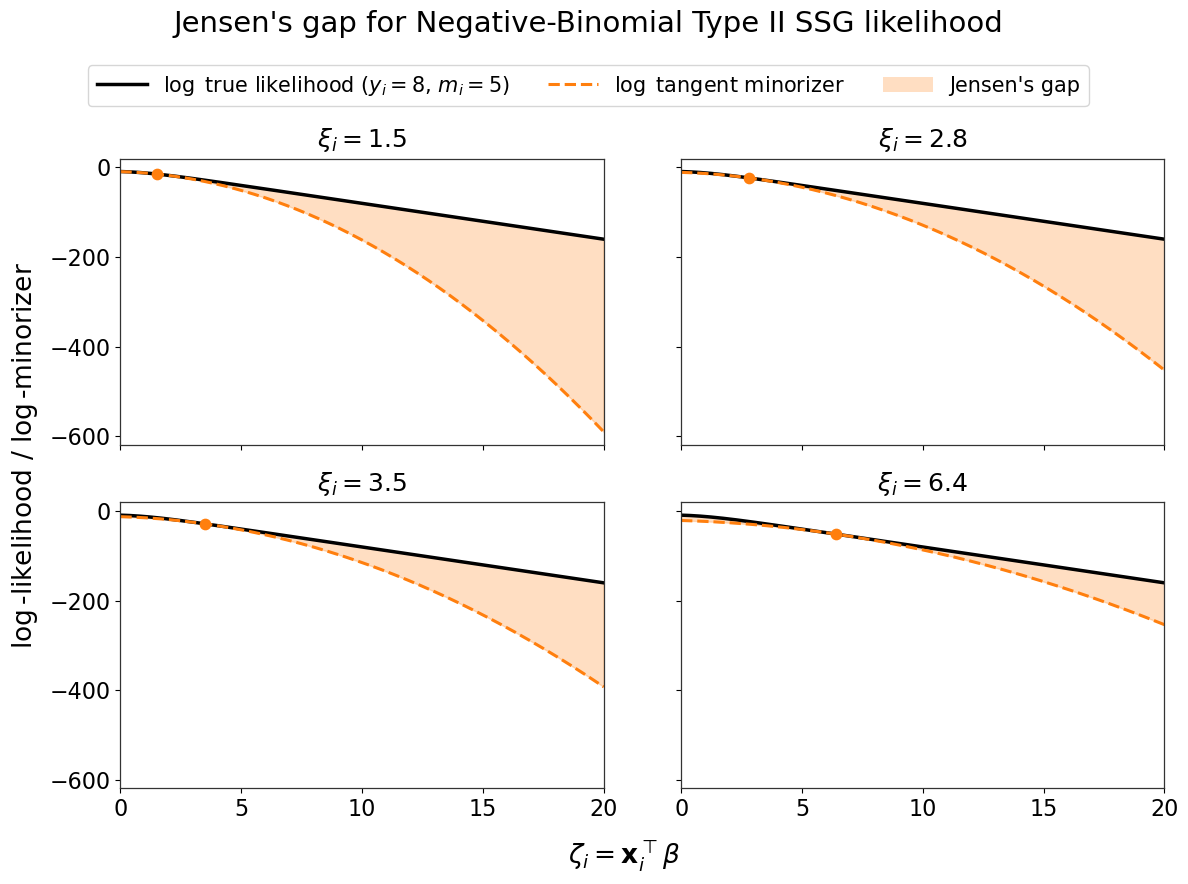

In [8]:
# ============================================================
# REQUIRED IMPORTS
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# SETTINGS
# ============================================================

y_i = 8.0
m_i = 5.0
xlim = 20.0


# ============================================================
# FUNCTIONS
# ============================================================

def nb_kernel(zeta, y, m):
    """
    Unnormalized Negative-Binomial likelihood kernel
    as a function of zeta.
    """
    return (
        np.exp(m * zeta)
        / (1.0 + np.exp(zeta)) ** (y + m)
    )


def log_nb_kernel(zeta, y, m):
    """
    Log of the unnormalized Negative-Binomial
    likelihood kernel.
    """
    return (
        m * zeta
        - (y + m) * np.logaddexp(0.0, zeta)
    )


def A(xi):
    """
    A(xi) = h'(xi^2) for the Type II SSG likelihood.
    """
    xi = np.asarray(xi, dtype=float)

    out = np.empty_like(xi)

    mask_zero = np.isclose(xi, 0.0)

    out[mask_zero] = -1.0 / 8.0

    out[~mask_zero] = (
        -np.tanh(xi[~mask_zero] / 2.0)
        / (4.0 * xi[~mask_zero])
    )

    return out if out.ndim > 0 else float(out)


def h_from_xi(xi):
    """
    h(xi^2) written directly in terms of xi >= 0.
    """
    return -np.log(
        2.0 * np.cosh(xi / 2.0)
    )


def gamma(xi):
    """
    gamma(xi) = h(xi^2) - xi^2 A(xi).
    """
    return (
        h_from_xi(xi)
        - xi**2 * A(np.array([xi]))[0]
    )


def tangent_minorizer(zeta, xi, y, m):
    """
    Unnormalized tangent minorizer phi(zeta | xi).
    """
    coeff_linear = 0.5 * (m - y)
    coeff_quad = (y + m) * A(np.array([xi]))[0]
    const_term = (y + m) * gamma(xi)

    return np.exp(
        coeff_linear * zeta
        + coeff_quad * zeta**2
        + const_term
    )


def log_tangent_minorizer(zeta, xi, y, m):
    """
    Log of the unnormalized tangent minorizer.
    """
    coeff_linear = 0.5 * (m - y)
    coeff_quad = (y + m) * A(np.array([xi]))[0]
    const_term = (y + m) * gamma(xi)

    return (
        coeff_linear * zeta
        + coeff_quad * zeta**2
        + const_term
    )


# ============================================================
# PLOT SETTINGS
# ============================================================

zeta = np.linspace(
    0.0,
    xlim,
    1500,
)

xi_values = [
    1.5,
    2.8,
    3.5,
    6.4,
]

colors = [
    "tab:orange",
    "tab:orange",
    "tab:orange",
    "tab:orange",
]

linestyles = [
    "--",
    "--",
    "--",
    "--",
]

markers = [
    "o",
    "o",
    "o",
    "o",
]


# ============================================================
# CREATE 2 x 2 PANEL
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
    sharex=True,
    sharey=True,
    facecolor="white",
)

axes = axes.flatten()

log_true = log_nb_kernel(
    zeta,
    y_i,
    m_i,
)

for ax, xi, color, linestyle, marker in zip(
    axes,
    xi_values,
    colors,
    linestyles,
    markers,
):
    log_phi = log_tangent_minorizer(
        zeta,
        xi,
        y_i,
        m_i,
    )

    # True log-likelihood
    ax.plot(
        zeta,
        log_true,
        color="black",
        linewidth=2.5,
    )

    # Tangent minorizer
    ax.plot(
        zeta,
        log_phi,
        color=color,
        linestyle=linestyle,
        linewidth=2.2,
    )

    # Highlight the Jensen gap
    ax.fill_between(
        zeta,
        log_phi,
        log_true,
        where=(log_true >= log_phi),
        color=color,
        alpha=0.25,
        interpolate=True,
    )

    # Tangency point
    y_tangent = log_nb_kernel(
        np.array([xi]),
        y_i,
        m_i,
    )[0]

    ax.scatter(
        [xi],
        [y_tangent],
        color=color,
        marker=marker,
        s=55,
        zorder=5,
    )

    ax.set_title(
        rf"$\xi_i = {xi}$",
        fontsize=18,
        pad=8,
    )

    ax.set_xlim(
        0.0,
        xlim,
    )

    ax.tick_params(
        axis="both",
        labelsize=16,
    )

    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_color("#333333")
        spine.set_linewidth(0.9)


# ============================================================
# COMMON AXIS LABELS
# ============================================================

fig.supxlabel(
    r"$\zeta_i=\mathbf{x}_i^{\top}\beta$",
    fontsize=19,
    x=0.53,
    y=0.025,
)

fig.supylabel(
    r"$\log$-likelihood / $\log$-minorizer",
    fontsize=19,
    x=0.018,
    y=0.49,
)


# ============================================================
# FIGURE TITLE
# ============================================================

fig.suptitle(
    r"Jensen's gap for Negative-Binomial Type II SSG likelihood",
    fontsize=21,
    y=0.985,
)


# ============================================================
# FIGURE-LEVEL LEGEND
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2.5,
        label=(
            r"$\log$ true likelihood "
            r"($y_i=8$, $m_i=5$)"
        ),
    ),
    Line2D(
        [0],
        [0],
        color="tab:orange",
        linewidth=2.2,
        linestyle="--",
        label=r"$\log$ tangent minorizer",
    ),
    Patch(
        facecolor="tab:orange",
        edgecolor="none",
        alpha=0.25,
        label=r"Jensen's gap",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=3,
    frameon=True,
    fontsize=15,
    columnspacing=1.8,
    handlelength=2.4,
)


# ============================================================
# LAYOUT
# ============================================================

fig.subplots_adjust(
    left=0.11,
    right=0.98,
    top=0.82,
    bottom=0.12,
    wspace=0.16,
    hspace=0.20,
)


# ============================================================
# SAVE FIGURE
# ============================================================

output_dir = Path("results_gaps/plots")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    output_dir
    / "nb_jensen_gap_highlighted.pdf"
)

fig.savefig(
    output_path,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

## ELBO Gap: Section C.2 of Supplementary Materials

### Comparison of $\mathsf{L}(\xi)$ and $\mathsf{L}_{\mathrm{true}}(\xi)$ over TAVIE-SSG iterations (Figure 3 of Supplementary Materials)

See `results_gaps/plots/tavie_true_elbo_gap_comparison.pdf`

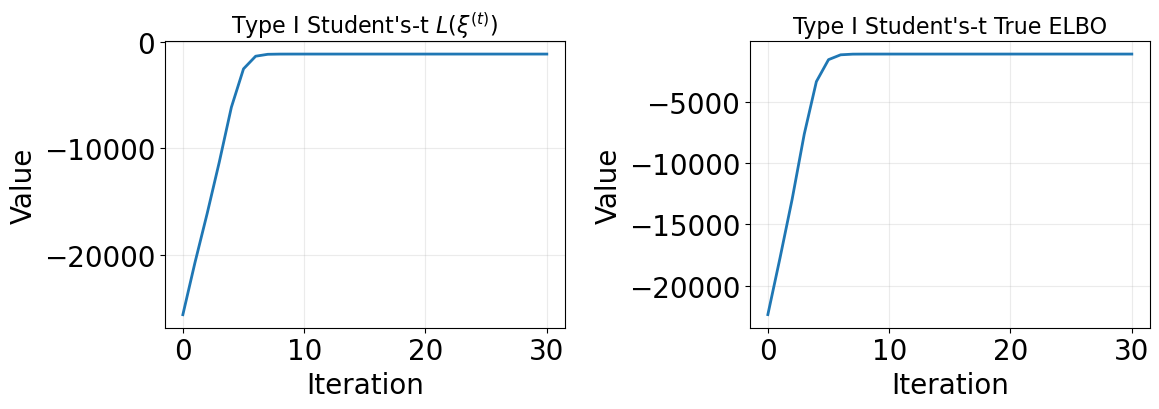

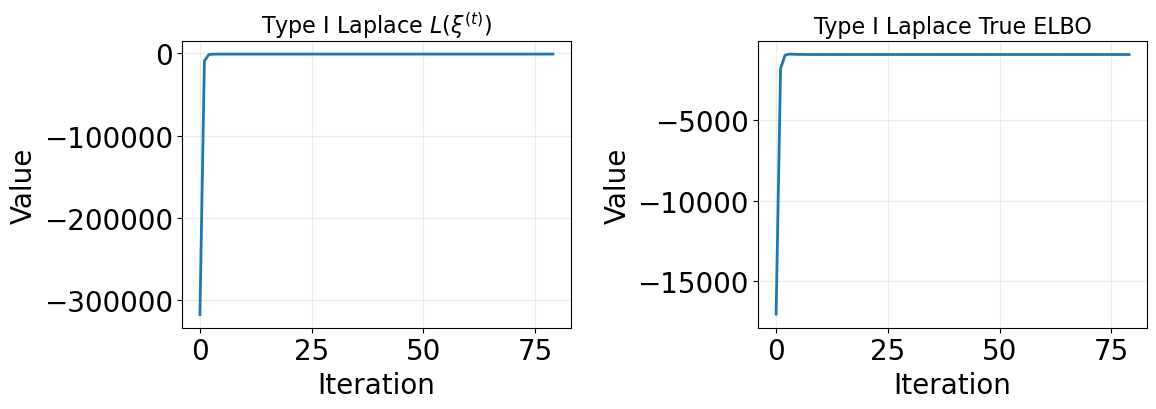

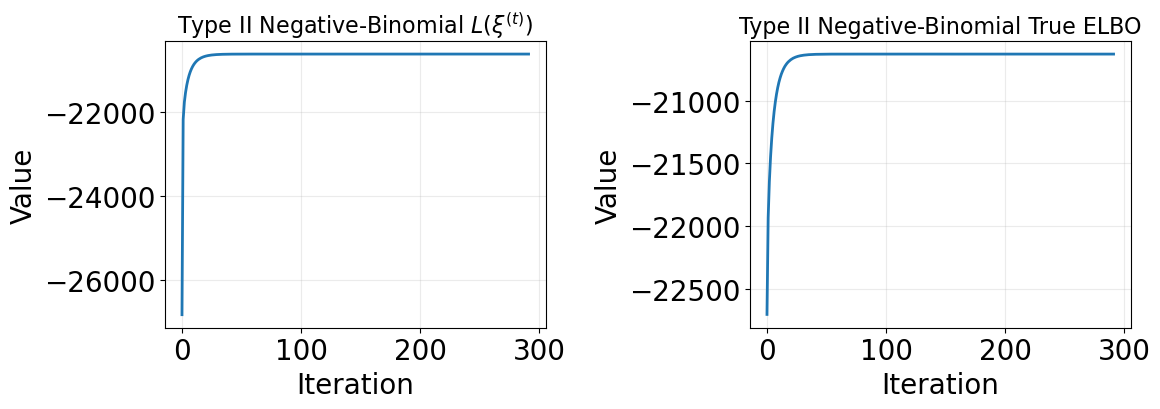

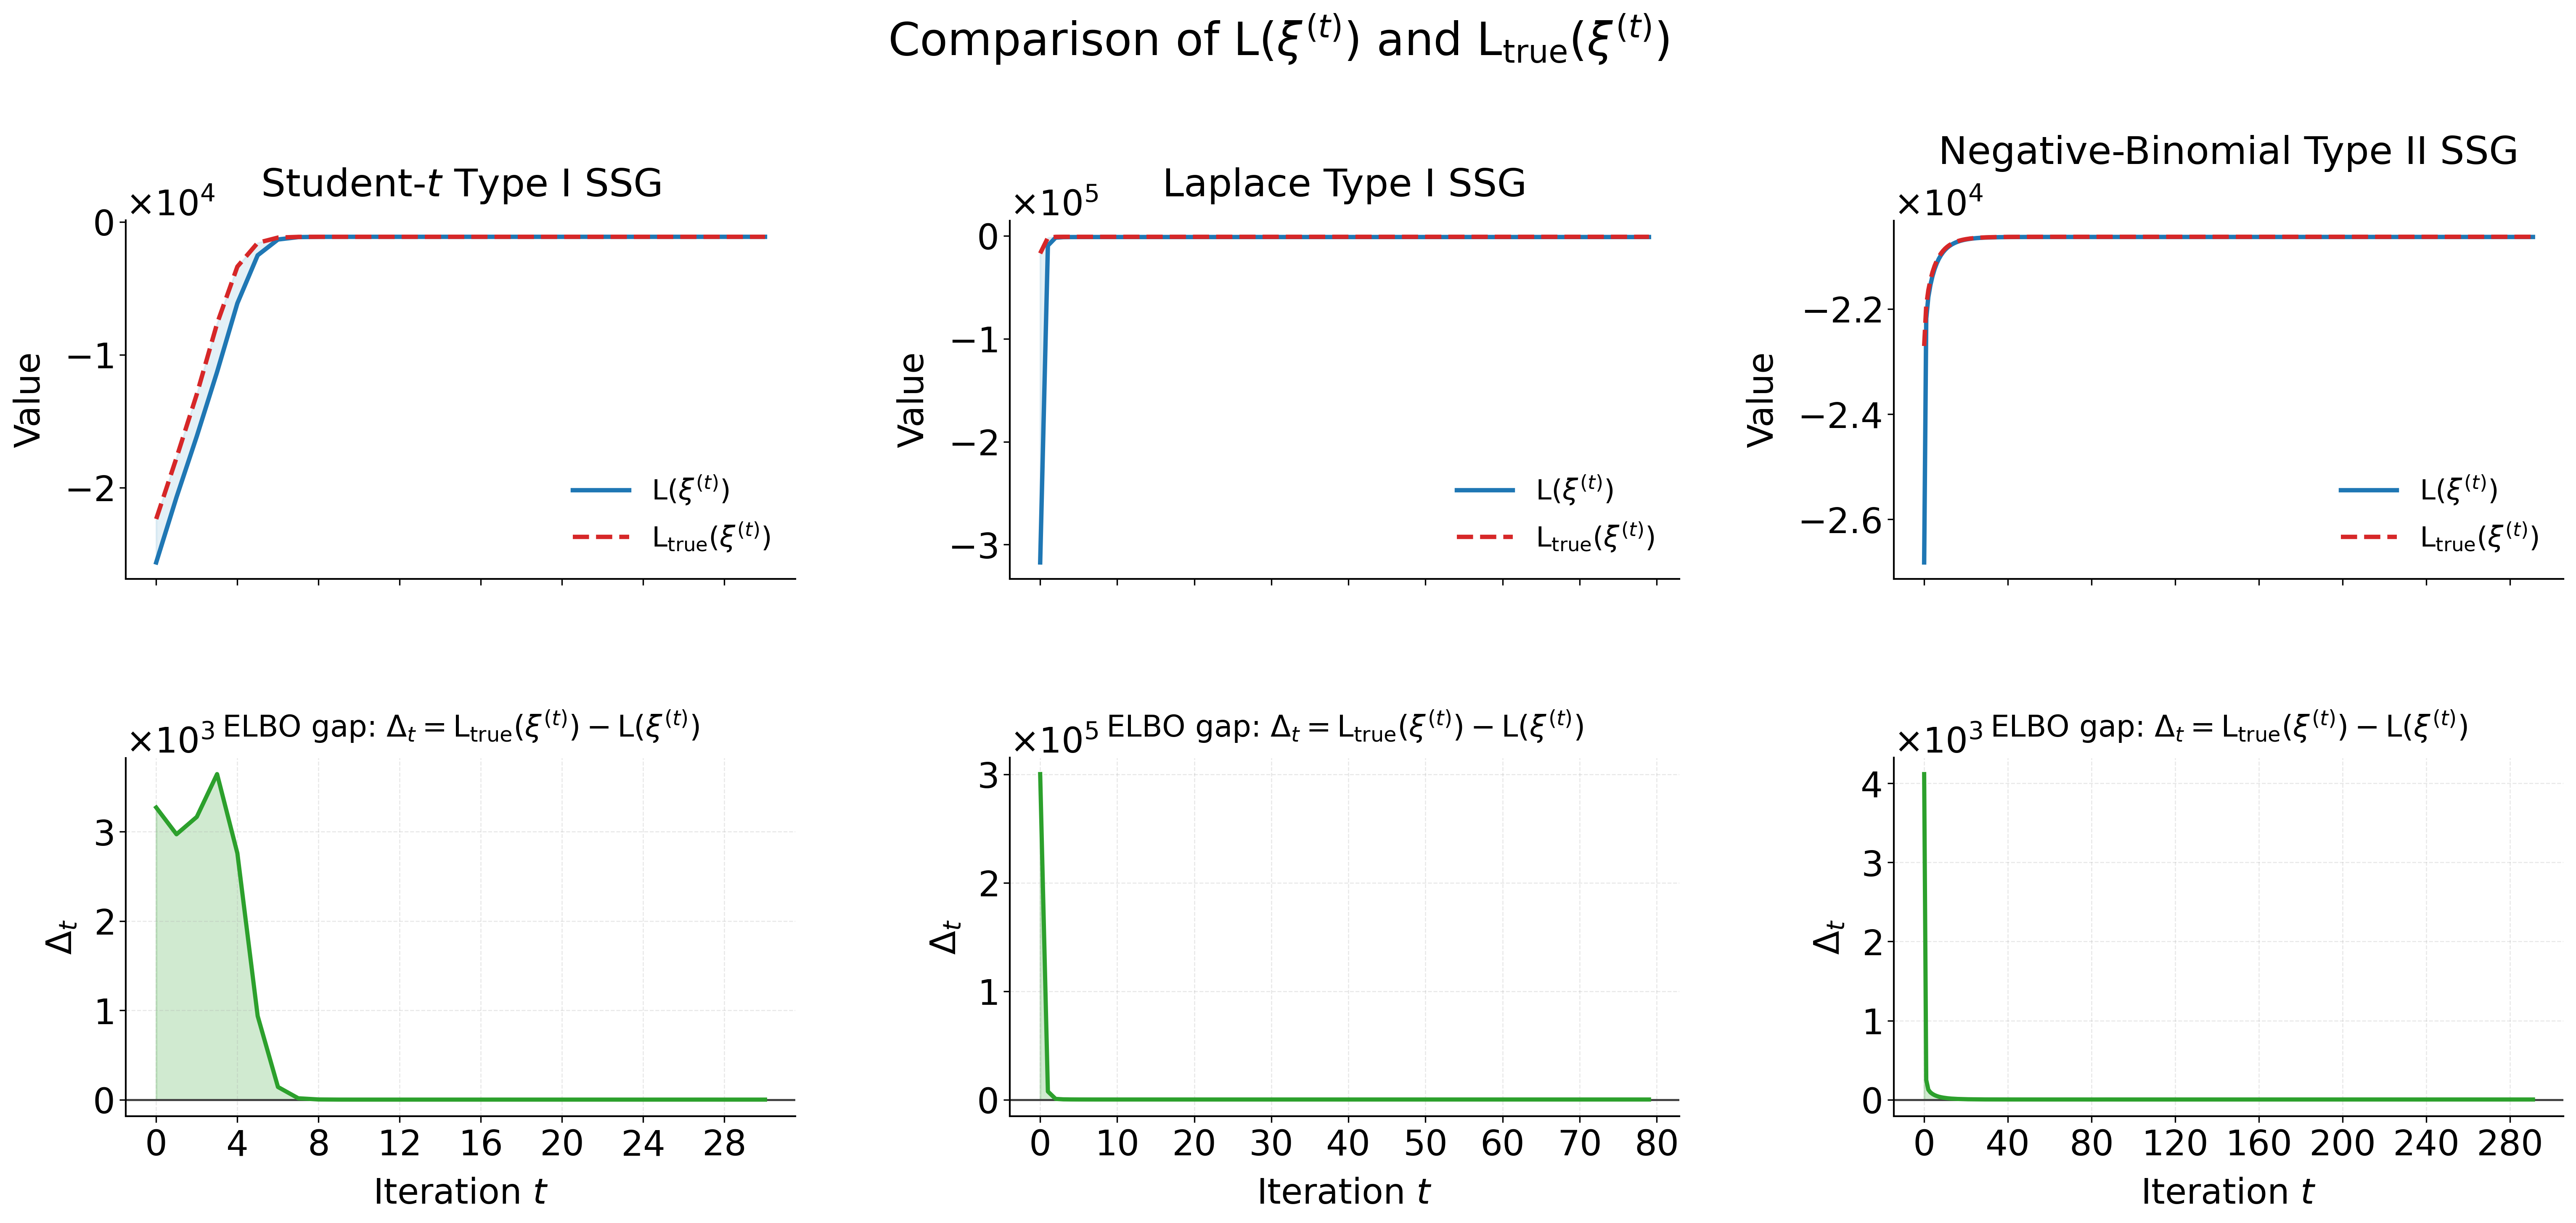

In [9]:
# ============================================================
# REQUIRED IMPORTS
# Use TAVIE_true_elbo for this analysis
# ============================================================

import os

import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple, List, Any
from numpy.linalg import cholesky, solve
from scipy.special import gammaln
from matplotlib.ticker import MaxNLocator, ScalarFormatter

from TAVIE_true_elbo import *
from TAVIE_true_elbo.compare_true_elbo import compare_type_I
from TAVIE_true_elbo.compare_true_elbo import compare_type_II


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_dir = "results_gaps/plots"
os.makedirs(output_dir, exist_ok=True)


# ============================================================
# STUDENT-t
# ============================================================

np.random.seed(123)

total_p = 9  # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 8
tau2_true = 3.0
df = 5
n = 1000

# True beta vector: intercept plus p coefficients
beta_true = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=p + 1,
)

# Prior
m0 = np.zeros(p + 1)
V0 = np.eye(p + 1)
a0 = 0.025
b0 = 0.025

# Simulate data
X = np.random.normal(
    size=(n, p),
)

error = (
    np.random.standard_t(
        df=df,
        size=n,
    )
    * (1.0 / np.sqrt(tau2_true))
)

y = (
    beta_true[0]
    + X @ beta_true[1:]
    + error
)

# Initialize and fit TAVIE
student_tavie_model = TAVIE_loc_scale(
    family="student",
    fit_intercept=True,
)

student_tavie_model.fit(
    X=X,
    y=y,
    prior_params=[m0, V0, a0, b0],
    alpha=1.0,
    maxiter=1000,
    tol=1e-9,
    verbose=False,
    nu=df,
)

# Compare L(xi) against the true ELBO
true_elbo_student, true_elbo_se_student = compare_type_I(
    model=student_tavie_model,
    prior_params=[m0, V0, a0, b0],
    family="student",
    nu=df,
    n_mc=1000,
    alpha=1.0,
    seed=123,
    title="Type I Student's-t",
)

# Raw tracked L(xi)
L_xi_student = student_tavie_model.get_elbo()


# ============================================================
# LAPLACE
# ============================================================

np.random.seed(123)

total_p = 9  # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 8
tau2_true = 3.0
n = 1000

# True beta vector
beta_true = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=p + 1,
)

# Prior
Sigma_prior = np.eye(p + 1)
m0 = np.zeros(p + 1)
V0 = np.eye(p + 1)
a0 = 0.025
b0 = 0.025

# Simulate data
X = np.random.normal(
    size=(n, p),
)

X_bbvi = np.column_stack(
    (
        np.ones(n),
        X,
    )
)

# Laplace parameterization:
# density = (tau / 2) exp(-tau |y - mu|)
# Var(error) = 2 / tau^2 = 2 / tau2_true
scale_laplace = 1.0 / np.sqrt(tau2_true)

error = np.random.laplace(
    loc=0.0,
    scale=scale_laplace,
    size=n,
)

y = (
    beta_true[0]
    + X @ beta_true[1:]
    + error
)

# Initialize and fit TAVIE
laplace_tavie_model = TAVIE_loc_scale(
    family="laplace",
    fit_intercept=True,
)

laplace_tavie_model.fit(
    X=X,
    y=y,
    prior_params=[m0, V0, a0, b0],
    alpha=1.0,
    maxiter=1000,
    tol=1e-9,
    verbose=False,
)

# Compare L(xi) against the true ELBO
true_elbo_laplace, true_elbo_se_laplace = compare_type_I(
    model=laplace_tavie_model,
    prior_params=[m0, V0, a0, b0],
    family="laplace",
    n_mc=1000,
    seed=123,
    title="Type I Laplace",
)

# Raw tracked L(xi)
L_xi_laplace = laplace_tavie_model.get_elbo()


# ============================================================
# NEGATIVE-BINOMIAL
# ============================================================

np.random.seed(123)

total_p = 9  # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 8
r = 10
n = 1000

# True beta vector
beta_true = np.random.normal(
    loc=0.0,
    scale=0.5,
    size=p + 1,
)

# Prior
Sigma_prior = np.eye(p + 1)
m0 = np.zeros(p + 1)
V0 = np.eye(p + 1)

# Simulate data
X = np.random.normal(
    size=(n, p),
)

X_bbvi = np.column_stack(
    (
        np.ones(n),
        X,
    )
)

linear_term = (
    beta_true[0]
    + X @ beta_true[1:]
)

probs = 1.0 / (
    1.0 + np.exp(-linear_term)
)

# NumPy parameterization:
# np.random.negative_binomial(n=r, p=probs)
y = np.random.negative_binomial(
    r,
    probs,
    size=n,
)

# Initialize and fit TAVIE
negbin_tavie_model = TAVIE_type_II(
    family="negbin",
    fit_intercept=True,
)

negbin_tavie_model.fit(
    X=X,
    y=y,
    r=r,
    prior_params=[m0, V0],
    alpha=1.0,
    maxiter=1000,
    tol=1e-9,
    verbose=False,
)

# Compare L(xi) against the true ELBO
true_elbo_negbin, true_elbo_se_negbin = compare_type_II(
    model=negbin_tavie_model,
    prior_params=[m0, V0],
    family="negbin",
    r=negbin_tavie_model.r,
    n_mc=1000,
    seed=123,
    title="Type II Negative-Binomial",
)

# Raw tracked L(xi)
L_xi_negbin = negbin_tavie_model.get_elbo()


# ============================================================
# GLOBAL PLOTTING STYLE
# ============================================================

plt.rcParams.update({
    "font.size": 25,
    "axes.titlesize": 25,
    "axes.labelsize": 25,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "figure.dpi": 300,
})

COLOR_L = "#1f77b4"       # blue
COLOR_TRUE = "#d62728"    # red
COLOR_GAP = "#2ca02c"     # green
COLOR_ZERO = "#444444"    # dark gray
SHADE_COLOR = "#9ecae1"   # soft blue


# ============================================================
# PLOTTING HELPERS
# ============================================================

def prettify_axis(ax, use_grid=False):
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    if use_grid:
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.6,
            alpha=0.30,
        )
    else:
        ax.grid(False)

    ax.xaxis.set_major_locator(
        MaxNLocator(integer=True)
    )

    ax.yaxis.set_major_formatter(
        ScalarFormatter(useMathText=True)
    )

    ax.ticklabel_format(
        style="sci",
        axis="y",
        scilimits=(-3, 3),
    )


def add_panel_label(ax, label):
    ax.text(
        0.02,
        0.96,
        label,
        transform=ax.transAxes,
        horizontalalignment="left",
        verticalalignment="top",
        fontsize=25,
        fontweight="bold",
    )


def plot_pair_with_gap(
    ax_top,
    ax_bottom,
    iterations,
    lower_bound,
    true_elbo,
    main_title,
    gap_title,
    panel_label="",
):
    gap = true_elbo - lower_bound

    # --------------------------------------------------------
    # Top plot: L(xi) versus true ELBO
    # --------------------------------------------------------

    ax_top.plot(
        iterations,
        lower_bound,
        label=r"$\mathsf{L}(\xi^{(t)})$",
        linewidth=2.5,
        color=COLOR_L,
    )

    ax_top.plot(
        iterations,
        true_elbo,
        label=r"$\mathsf{L}_{\mathrm{true}}(\xi^{(t)})$",
        linewidth=2.5,
        linestyle="--",
        color=COLOR_TRUE,
    )

    ax_top.fill_between(
        iterations,
        lower_bound,
        true_elbo,
        where=(gap >= 0),
        color=SHADE_COLOR,
        alpha=0.28,
    )

    ax_top.set_title(
        main_title,
        fontsize=22,
        pad=14,
    )

    ax_top.set_ylabel(
        "Value",
        fontsize=20,
        labelpad=10,
    )

    ax_top.legend(
        loc="best",
        frameon=False,
        fontsize=16,
    )

    prettify_axis(
        ax_top,
        use_grid=False,
    )

    if panel_label:
        add_panel_label(
            ax_top,
            panel_label,
        )

    # --------------------------------------------------------
    # Bottom plot: ELBO gap
    # --------------------------------------------------------

    ax_bottom.axhline(
        0.0,
        color=COLOR_ZERO,
        linewidth=1.2,
        linestyle="-",
    )

    ax_bottom.plot(
        iterations,
        gap,
        linewidth=2.4,
        color=COLOR_GAP,
    )

    ax_bottom.fill_between(
        iterations,
        0.0,
        gap,
        where=(gap >= 0),
        color=COLOR_GAP,
        alpha=0.22,
    )

    ax_bottom.set_title(
        gap_title,
        fontsize=17,
        pad=12,
    )

    ax_bottom.set_xlabel(
        r"Iteration $t$",
        fontsize=20,
        labelpad=8,
    )

    ax_bottom.set_ylabel(
        r"$\Delta_t$",
        fontsize=20,
        labelpad=8,
    )

    prettify_axis(
        ax_bottom,
        use_grid=True,
    )

    return gap


# ============================================================
# FLATNESS DETECTION
# ============================================================

def find_flat_start(y, tol=1e-3, window=5):
    y = np.asarray(
        y,
        dtype=float,
    )

    if len(y) <= window + 1:
        return 0

    differences = np.abs(
        np.diff(y)
    )

    for t in range(
        len(differences) - window + 1
    ):
        if np.all(
            differences[t:t + window] < tol
        ):
            return t

    return 0


def flat_start_for_pair(
    lower_bound,
    true_elbo,
    tol=1e-3,
    window=5,
):
    lower_bound_start = find_flat_start(
        lower_bound,
        tol=tol,
        window=window,
    )

    true_elbo_start = find_flat_start(
        true_elbo,
        tol=tol,
        window=window,
    )

    return max(
        lower_bound_start,
        true_elbo_start,
    )


# ============================================================
# CONVERT RESULTS TO ARRAYS
# ============================================================

L_xi_student = np.asarray(
    L_xi_student,
    dtype=float,
)

true_elbo_student = np.asarray(
    true_elbo_student,
    dtype=float,
)

L_xi_laplace = np.asarray(
    L_xi_laplace,
    dtype=float,
)

true_elbo_laplace = np.asarray(
    true_elbo_laplace,
    dtype=float,
)

L_xi_negbin = np.asarray(
    L_xi_negbin,
    dtype=float,
)

true_elbo_negbin = np.asarray(
    true_elbo_negbin,
    dtype=float,
)


# ============================================================
# CREATE THE FULL-RANGE 2 x 3 FIGURE
# ============================================================

# Manual spacing is used instead of constrained_layout so that
# sufficient room can be reserved for the main title, panel
# titles, axis labels, and space between panels.
fig, axes = plt.subplots(
    2,
    3,
    figsize=(21, 10),
    sharex="col",
    constrained_layout=False,
    facecolor="white",
)


# ============================================================
# COLUMN 1: STUDENT-t
# ============================================================

T1 = min(
    len(L_xi_student),
    len(true_elbo_student),
)

iterations_student = np.arange(T1)

gap_student = plot_pair_with_gap(
    ax_top=axes[0, 0],
    ax_bottom=axes[1, 0],
    iterations=iterations_student,
    lower_bound=L_xi_student[:T1],
    true_elbo=true_elbo_student[:T1],
    main_title=r"Student-$t$ Type I SSG",
    gap_title=(
        r"ELBO gap: "
        r"$\Delta_t="
        r"\mathsf{L}_{\mathrm{true}}(\xi^{(t)})"
        r"-\mathsf{L}(\xi^{(t)})$"
    ),
    panel_label="",
)


# ============================================================
# COLUMN 2: LAPLACE
# ============================================================

T2 = min(
    len(L_xi_laplace),
    len(true_elbo_laplace),
)

iterations_laplace = np.arange(T2)

gap_laplace = plot_pair_with_gap(
    ax_top=axes[0, 1],
    ax_bottom=axes[1, 1],
    iterations=iterations_laplace,
    lower_bound=L_xi_laplace[:T2],
    true_elbo=true_elbo_laplace[:T2],
    main_title="Laplace Type I SSG",
    gap_title=(
        r"ELBO gap: "
        r"$\Delta_t="
        r"\mathsf{L}_{\mathrm{true}}(\xi^{(t)})"
        r"-\mathsf{L}(\xi^{(t)})$"
    ),
    panel_label="",
)


# ============================================================
# COLUMN 3: NEGATIVE-BINOMIAL
# ============================================================

T3 = min(
    len(L_xi_negbin),
    len(true_elbo_negbin),
)

iterations_negbin = np.arange(T3)

gap_negbin = plot_pair_with_gap(
    ax_top=axes[0, 2],
    ax_bottom=axes[1, 2],
    iterations=iterations_negbin,
    lower_bound=L_xi_negbin[:T3],
    true_elbo=true_elbo_negbin[:T3],
    main_title="Negative-Binomial Type II SSG",
    gap_title=(
        r"ELBO gap: "
        r"$\Delta_t="
        r"\mathsf{L}_{\mathrm{true}}(\xi^{(t)})"
        r"-\mathsf{L}(\xi^{(t)})$"
    ),
    panel_label="",
)


# ============================================================
# MAIN FIGURE TITLE
# ============================================================

fig.suptitle(
    r"Comparison of $\mathsf{L}(\xi^{(t)})$ and "
    r"$\mathsf{L}_{\mathrm{true}}(\xi^{(t)})$",
    fontsize=26,
    y=0.975,
)


# ============================================================
# SUBPLOT SPACING
# ============================================================

# top=0.81 reserves a large margin between the main title and
# the three top-row subplot titles.
#
# wspace=0.32 adds horizontal space between the three columns.
#
# hspace=0.50 adds vertical space between the ELBO curves and
# their corresponding gap panels.
fig.subplots_adjust(
    left=0.065,
    right=0.985,
    top=0.81,
    bottom=0.10,
    wspace=0.32,
    hspace=0.50,
)


# ============================================================
# SAVE AND DISPLAY
# ============================================================

output_path = os.path.join(
    output_dir,
    "tavie_true_elbo_gap_comparison.pdf",
)

fig.savefig(
    output_path,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

## Empirical Complexity Analyis of ELBO and Variational Gaps: Section C.4 of Supplementary Materials

### Post-convergence $\mathsf{ELBO}$ gap $\mathsf{L}_{\mathrm{true}}(\xi^{\star}) - \mathsf{L}(\xi^{\star})$

See: `results_gaps/student_t_postconv_gap_fix_n_vary_p.csv`

In [2]:
# required imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from TAVIE_true_elbo import *
from TAVIE_true_elbo.compare_true_elbo import compare_type_I

# ============================================================
# Fixed experiment settings
# ============================================================
seed_global = 123
np.random.seed(seed_global)

tau2_true = 3.0
df = 5
alpha = 1.0

# Prior
a0, b0 = 0.025, 0.025

n_fixed = 1000
total_p_values = [9, 16, 21, 26] # total_p_values = p_values + 1
p_values = [8, 15, 20, 25]

num_reps = 20

# TAVIE / MC settings
maxiter = 1000
tol = 1e-9
n_mc = 1000

# ============================================================
# Post-convergence gap settings
# ============================================================
tail_fraction = 0.10       # use last 20% iterations
gap_summary = "mean_tail"  # options: "mean_tail", "median_tail", "last"

# ============================================================
# Data generation helpers
# ============================================================
def generate_student_data(n, p, beta_true, tau2_true, df, seed=123):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))
    error = rng.standard_t(df=df, size=n) * (1.0 / np.sqrt(tau2_true))
    y = beta_true[0] + X @ beta_true[1:] + error
    return X, y

def summarize_post_convergence_gap(gap_trace, tail_fraction=0.20, method="mean_tail"):
    """
    gap_trace = L_true - L_xi over iterations
    """
    gap_trace = np.asarray(gap_trace, dtype=float)
    T = len(gap_trace)
    start = max(0, int(np.floor((1.0 - tail_fraction) * T)))
    tail = gap_trace[start:]

    if method == "mean_tail":
        return float(np.mean(tail))
    elif method == "median_tail":
        return float(np.median(tail))
    elif method == "last":
        return float(gap_trace[-1])
    else:
        raise ValueError(f"Unknown method: {method}")

def fit_student_and_gap(n, p, beta_true, tau2_true, df, alpha, a0, b0,
                        maxiter=1000, tol=1e-9, n_mc=1000, seed=123,
                        tail_fraction=0.20, gap_summary="mean_tail"):
    # Prior
    m0 = np.zeros(p + 1)
    V0 = np.eye(p + 1)

    # Data
    X, y = generate_student_data(
        n=n,
        p=p,
        beta_true=beta_true,
        tau2_true=tau2_true,
        df=df,
        seed=seed + 100
    )

    # Fit TAVIE
    model = TAVIE_loc_scale(family="student", fit_intercept=True)
    model.fit(
        X=X,
        y=y,
        prior_params=[m0, V0, a0, b0],
        alpha=alpha,
        maxiter=maxiter,
        tol=tol,
        verbose=False,
        nu=df
    )

    # Surrogate objective
    L_xi = np.asarray(model.get_elbo(), dtype=float)

    # True ELBO trajectory
    true_elbo, true_elbo_se = compare_type_I(
        model=model,
        prior_params=[m0, V0, a0, b0],
        family="student",
        nu=df,
        n_mc=n_mc,
        alpha=alpha,
        seed=seed,
        title=f"Type I Student's-t: n={n}, p={p}"
    )

    true_elbo = np.asarray(true_elbo, dtype=float)

    # Align lengths
    T = min(len(L_xi), len(true_elbo))
    L_xi = L_xi[:T]
    L_true = true_elbo[:T]

    gap_trace = L_true - L_xi
    post_gap = summarize_post_convergence_gap(
        gap_trace,
        tail_fraction=tail_fraction,
        method=gap_summary
    )

    return {
        "gap_postconv": post_gap,
        "gap_trace": gap_trace,
        "L_xi": L_xi,
        "L_true": L_true
    }

# ============================================================
# Fixed beta choices
#   - for varying n: one beta vector fixed across all reps and n
#   - for varying p: one beta vector fixed for each p across reps
# ============================================================
rng_master = np.random.default_rng(seed_global)

beta_true_by_p = {
    p: np.random.default_rng(seed_global + 1000 + p).normal(loc=0.0, scale=1.0, size=p + 1)
    for p in p_values
}

# ============================================================
# Fix n, vary p: collect post-convergence gaps
# ============================================================
records_p = []

for p in p_values:
    print(f"\nRunning Student-t boxplot experiment with fixed n={n_fixed}, p={p}")
    for rep in range(1, num_reps + 1):
        print(f"  repetition {rep}/{num_reps}")
        seed_rep = seed_global + 20000 * rep + p

        out = fit_student_and_gap(
            n=n_fixed,
            p=p,
            beta_true=beta_true_by_p[p],
            tau2_true=tau2_true,
            df=df,
            alpha=alpha,
            a0=a0,
            b0=b0,
            maxiter=maxiter,
            tol=tol,
            n_mc=n_mc,
            seed=seed_rep,
            tail_fraction=tail_fraction,
            gap_summary=gap_summary
        )

        records_p.append({
            "setting_type": "vary_p",
            "n": n_fixed,
            "total_p": p + 1,
            "rep": rep,
            "gap_postconv": out["gap_postconv"]
        })

df_p = pd.DataFrame(records_p)
df_p.to_csv("results_gaps/student_t_postconv_gap_fix_n_vary_p.csv",
    index=False
)


Running Student-t boxplot experiment with fixed n=1000, p=8
  repetition 1/20
  repetition 2/20
  repetition 3/20
  repetition 4/20
  repetition 5/20
  repetition 6/20
  repetition 7/20
  repetition 8/20
  repetition 9/20
  repetition 10/20
  repetition 11/20
  repetition 12/20
  repetition 13/20
  repetition 14/20
  repetition 15/20
  repetition 16/20
  repetition 17/20
  repetition 18/20
  repetition 19/20
  repetition 20/20

Running Student-t boxplot experiment with fixed n=1000, p=15
  repetition 1/20
  repetition 2/20
  repetition 3/20
  repetition 4/20
  repetition 5/20
  repetition 6/20
  repetition 7/20
  repetition 8/20
  repetition 9/20
  repetition 10/20
  repetition 11/20
  repetition 12/20
  repetition 13/20
  repetition 14/20
  repetition 15/20
  repetition 16/20
  repetition 17/20
  repetition 18/20
  repetition 19/20
  repetition 20/20

Running Student-t boxplot experiment with fixed n=1000, p=20
  repetition 1/20
  repetition 2/20
  repetition 3/20
  repetition 4/20
 

### Figure 4 of Supplementary Materials

See `results_gaps/plots/student_t_boxplot_postconv_elbo_gap_fix_n_vary_p.pdf`

/var/folders/w0/38zdqgkd1dlclgzfl906wb400000gn/T/ipykernel_69055/3580266905.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


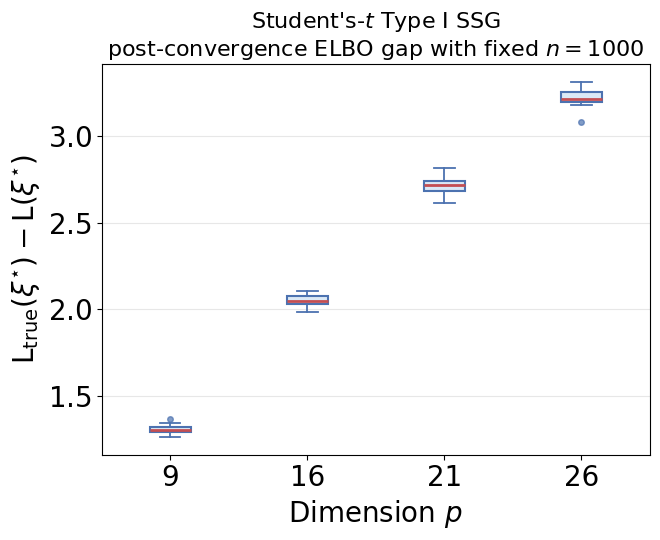

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df_p = pd.read_csv("results_gaps/student_t_postconv_gap_fix_n_vary_p.csv")

# ============================================================
# Recover plotting metadata from saved data
# ============================================================
p_values = sorted(df_p["total_p"].unique().tolist())
n_fixed = int(df_p["n"].iloc[0])

num_reps_p = df_p.groupby("total_p")["rep"].nunique().min()
num_reps = num_reps_p

# ============================================================
# Global plotting style
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 16,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20
})

# ============================================================
# Custom colors
# ============================================================
COLOR_BOX = "#dbe9f6"
COLOR_MEDIAN = "#c44e52"
COLOR_EDGE = "#4c72b0"
COLOR_GRID = "#d0d0d0"

# ============================================================
# Plotting helper
# ============================================================
def make_boxplot(ax, groups, labels, title, xlabel):
    ax.boxplot(
        groups,
        patch_artist=True,
        labels=labels,
        widths=0.3,
        medianprops=dict(color=COLOR_MEDIAN, linewidth=2.0),
        boxprops=dict(facecolor=COLOR_BOX, edgecolor=COLOR_EDGE, linewidth=1.5),
        whiskerprops=dict(color=COLOR_EDGE, linewidth=1.3),
        capprops=dict(color=COLOR_EDGE, linewidth=1.3),
        flierprops=dict(
            marker='o',
            markerfacecolor=COLOR_EDGE,
            markeredgecolor=COLOR_EDGE,
            markersize=4,
            alpha=0.7
        )
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(
        r"$\mathsf{L}_{\mathrm{true}}(\xi^{\star})-\mathsf{L}(\xi^{\star})$"
    )
    ax.grid(axis="y", color=COLOR_GRID, alpha=0.5)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

groups_p = [df_p.loc[df_p["total_p"] == p, "gap_postconv"].values for p in p_values]
labels_p = [str(p) for p in p_values]

fig, ax = plt.subplots(figsize=(7.0, 5.8))
make_boxplot(
    ax=ax,
    groups=groups_p,
    labels=labels_p,
    title=rf"Student's-$t$ Type I SSG" + "\n" +
    rf"post-convergence ELBO gap with fixed $n={n_fixed}$",
    xlabel=r"Dimension $p$"
)

fig.tight_layout()
fig.savefig(
    os.path.join("results_gaps/plots/student_t_boxplot_postconv_elbo_gap_fix_n_vary_p.pdf"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Posterior Concentration plots: Section C.5 of Supplementary Materials

In [ ]:
# required imports
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from tqdm.auto import trange
import pymc as pm
import pytensor
import pytensor.tensor as pt
from matplotlib.patches import Patch
import jax
import jax.numpy as jnp
setattr(jnp, "product", jnp.prod)
jax.config.update("jax_enable_x64", True)
from CompetingMethods import *
from dadvi.pymc.jax_api import fit_pymc_dadvi_with_jax
from TAVIE import *
import rich
from sklearn.preprocessing import scale
from IPython.display import display, Latex
from time import perf_counter
from tqdm import tqdm, trange
from scipy.stats import t
import arviz as az
import re
from scipy.special import gammaln
from scipy.stats import gaussian_kde

# ============================================================
# SETTINGS
# ============================================================
p = 8
tau2_true = 3.0
df = 5
alpha = 1.0
n_values = [1000, 2000]

# coordinates of beta to visualize
beta_idx1 = 1
beta_idx2 = 2

# global fixed true beta
np.random.seed(123)
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p + 1)

Sigma_prior = np.eye(p + 1)
a0 = 0.025
b0 = 0.025

output_dir = "results_gaps/contour_plots"
os.makedirs(output_dir, exist_ok=True)


# ============================================================
# DATA GENERATION
# ============================================================
def generate_student_regression_data(n, p, beta_true, tau2_true, df, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))
    error = rng.standard_t(df=df, size=n) / np.sqrt(tau2_true)
    y = beta_true[0] + X @ beta_true[1:] + error
    return X, y


# ============================================================
# PYMC MODEL FOR TRUE POSTERIOR
# ============================================================
def student_fractional_pymc_model(X, y, nu, alpha=1.0, prior_var=10.0, a0=0.005, b0=0.005):
    X = np.asarray(X)
    y = np.asarray(y)

    if X.ndim == 1:
        X = X.reshape(-1, 1)

    n_local, p_local = X.shape
    X_with_intercept = np.column_stack((np.ones(n_local), X))

    dtype = np.dtype(pytensor.config.floatX)
    X_with_intercept = X_with_intercept.astype(dtype)
    y = y.astype(dtype)

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_with_intercept)
        y_data = pm.Data("y_data", y)

        beta = pm.Normal("beta", mu=0.0, sigma=np.sqrt(prior_var), shape=p_local + 1)
        tau2 = pm.Gamma("tau2", alpha=a0 / 2.0, beta=b0 / 2.0)

        mu = pt.dot(X_data, beta)
        sigma = 1.0 / pt.sqrt(tau2)

        loglik_vec = pm.logp(pm.StudentT.dist(nu=nu, mu=mu, sigma=sigma), y_data)
        pm.Potential("frac_loglik", alpha * pt.sum(loglik_vec))

    return model


def student_fractional_pymc_model_with_intercept_design(
    X_bbvi, y, nu, alpha=1.0, prior_var=10.0, a0=0.005, b0=0.005
):
    X_bbvi = np.asarray(X_bbvi)
    y = np.asarray(y)

    dtype = np.dtype(pytensor.config.floatX)
    X_bbvi = X_bbvi.astype(dtype)
    y = y.astype(dtype)

    n_local, p1 = X_bbvi.shape

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_bbvi)
        y_data = pm.Data("y_data", y)

        beta = pm.Normal("beta", mu=0.0, sigma=np.sqrt(prior_var), shape=p1)
        tau2 = pm.Gamma("tau2", alpha=a0 / 2.0, beta=b0 / 2.0)

        mu = pt.dot(X_data, beta)
        sigma = 1.0 / pt.sqrt(tau2)

        loglik_vec = pm.logp(pm.StudentT.dist(nu=nu, mu=mu, sigma=sigma), y_data)
        pm.Potential("frac_loglik", alpha * pt.sum(loglik_vec))

    return model


def fit_NUTS_student_fractional(
    model,
    draws=10000,
    tune=1000,
    chains=5,
    target_accept=0.9,
    random_seed=123
):
    with model:
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=1,
            target_accept=target_accept,
            progressbar=False,
            compute_convergence_checks=False,
            random_seed=random_seed,
            return_inferencedata=True
        )
    return idata


# ============================================================
# EXTRACT BETA DRAWS
# ============================================================
def extract_beta_draws_2d(idata, beta_idx1, beta_idx2):
    beta_draws = idata.posterior["beta"].stack(sample=("chain", "draw")).values

    if beta_draws.shape[0] < beta_draws.shape[1]:
        beta1 = beta_draws[beta_idx1, :]
        beta2 = beta_draws[beta_idx2, :]
    else:
        beta1 = beta_draws[:, beta_idx1]
        beta2 = beta_draws[:, beta_idx2]

    return np.vstack([beta1, beta2])


def extract_beta_draws_2d_from_z(z_samples, beta_idx1, beta_idx2):
    z_samples = np.asarray(z_samples)
    beta1 = z_samples[:, beta_idx1]
    beta2 = z_samples[:, beta_idx2]
    return np.vstack([beta1, beta2])


# ============================================================
# KDE ON 2D POSTERIOR DRAWS
# ============================================================
def kde_density_2d(samples_2d, XX, YY, bw_method=None):
    kde = gaussian_kde(samples_2d, bw_method=bw_method)
    grid_points = np.vstack([XX.ravel(), YY.ravel()])
    Z = kde(grid_points).reshape(XX.shape)
    return Z


# ============================================================
# MULTIVARIATE t PDF IN 2D FOR TAVIE MARGINAL
# beta ~ t_nu(mu, S), S = (b_xi / a_xi) V_xi
# ============================================================
def multivariate_t_pdf_2d(X, Y, mu, S, nu):
    d = 2
    pos = np.dstack((X, Y))

    S_inv = np.linalg.inv(S)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        raise ValueError("Scale matrix must be positive definite.")

    diff = pos - mu
    qf = np.einsum("...i,ij,...j->...", diff, S_inv, diff)

    log_const = (
        gammaln((nu + d) / 2.0)
        - gammaln(nu / 2.0)
        - (d / 2.0) * np.log(nu * np.pi)
        - 0.5 * logdet
    )
    log_kernel = -((nu + d) / 2.0) * np.log1p(qf / nu)

    return np.exp(log_const + log_kernel)


# ============================================================
# COMMON UNIFORM CONTOUR LEVELS
# ============================================================
def common_uniform_levels(Z_list, num_levels=12):
    vals_all = []
    for Z in Z_list:
        vals = Z[np.isfinite(Z)]
        vals = vals[vals > 0]
        if len(vals) > 0:
            vals_all.append(vals)

    all_vals = np.concatenate(vals_all)
    zmin = all_vals.min()
    zmax = all_vals.max()

    levels = np.linspace(zmin, zmax, num_levels)
    levels[-1] = zmax
    levels = np.unique(levels)
    return levels


# ============================================================
# TAVIE FIT AND EXTRACTION
# ============================================================
def fit_tavie_student_and_extract(X, y, nu, alpha):
    p_local = X.shape[1]
    prior_params = [np.zeros(p_local + 1), 10.0 * np.eye(p_local + 1), 0.005, 0.005]

    model = TAVIE_loc_scale(family="student", fit_intercept=True)
    model.fit(X, y, nu=nu, alpha=alpha, prior_params=prior_params, verbose=False)

    ve = model.get_variational_estimates()

    return {
        "model": model,
        "m_xi": np.asarray(ve["m_xi"]),
        "V_xi": np.asarray(ve["V_xi"]),
        "a_xi": float(ve["a_xi"]),
        "b_xi": float(ve["b_xi"]),
    }


# ============================================================
# MFVI SAMPLING
# ============================================================
def sample_mfvi_student_z(beta_mean, beta_cov, tau2_shape, tau2_rate, n_samples, seed=123):
    rng = np.random.default_rng(seed)

    beta_mean = np.asarray(beta_mean, dtype=float).reshape(-1)
    beta_cov = np.asarray(beta_cov, dtype=float)
    beta_cov = 0.5 * (beta_cov + beta_cov.T)

    beta_draws = rng.multivariate_normal(mean=beta_mean, cov=beta_cov, size=n_samples)
    tau2_draws = rng.gamma(shape=tau2_shape, scale=1.0 / tau2_rate, size=n_samples)
    log_tau2_draws = np.log(tau2_draws)

    return np.column_stack([beta_draws, log_tau2_draws])


def fit_mfvi_student_and_sample_z(
    X_bbvi,
    y,
    n_samples,
    p,
    nu_fixed=5,
    seed=123,
    max_iter=500,
    tol=1e-6,
    verbose=False
):
    res = MFVI_Student(
        X=X_bbvi,
        y=y,
        mu_beta=np.zeros(p + 1),
        Sigma_beta=np.eye(p + 1),
        A=2.0,
        B=2.0,
        nu_min=2.0,
        nu_max=20.0,
        max_iter=max_iter,
        tol=tol,
        nu_grid=500,
        fix_nu=nu_fixed,
        verbose=verbose
    )

    z = sample_mfvi_student_z(
        beta_mean=res["beta_mean"],
        beta_cov=res["beta_cov"],
        tau2_shape=res["tau2_shape"],
        tau2_rate=res["tau2_rate"],
        n_samples=n_samples,
        seed=seed
    )

    return z, res


# ============================================================
# ADVI MF
# ============================================================
def sample_student_advi_mf_z(q_mu, q_sd, q_alpha_shape, q_tau_rate, n_samples, seed=123):
    rng = np.random.default_rng(seed)

    q_mu = np.asarray(q_mu, dtype=float).reshape(-1)
    q_sd = np.asarray(q_sd, dtype=float).reshape(-1)
    d = q_mu.shape[0]

    beta_draws = q_mu[None, :] + rng.normal(size=(n_samples, d)) * q_sd[None, :]
    tau2_draws = rng.gamma(shape=q_alpha_shape, scale=1.0 / q_tau_rate, size=n_samples)
    return np.column_stack([beta_draws, np.log(tau2_draws)])


def fit_student_advi_mf_and_sample_z(X_bbvi, y, nu, a0, b0, n_samples, seed=123):
    res = BBVI_student_patience_best(
        X=X_bbvi, y=y, nu=nu, a0=a0, b0=b0,
        num_iters=20000, lr=1e-3, tol=1e-8, patience=1000,
        weight_decay=1e-2, verbose=False
    )
    z = sample_student_advi_mf_z(
        res["q_mu"], res["q_sd"], res["q_alpha_shape"], res["q_tau_rate"],
        n_samples=n_samples, seed=seed
    )
    return z, res


# ============================================================
# ADVI FR
# ============================================================
def sample_student_advi_fr_z(q_mu, q_L, q_alpha_shape, q_tau_rate, n_samples, seed=123):
    rng = np.random.default_rng(seed)

    q_mu = np.asarray(q_mu, dtype=float).reshape(-1)
    q_L = np.asarray(q_L, dtype=float)
    d = q_mu.shape[0]

    eps = rng.normal(size=(n_samples, d))
    beta_draws = q_mu[None, :] + eps @ q_L.T
    tau2_draws = rng.gamma(shape=q_alpha_shape, scale=1.0 / q_tau_rate, size=n_samples)

    return np.column_stack([beta_draws, np.log(tau2_draws)])


def fit_student_advi_fr_and_sample_z(X_bbvi, y, nu, Sigma_prior, a0, b0, n_samples, seed=123):
    res = BBVI_student_fullcov_AdamW_best(
        X=X_bbvi, y=y, nu=nu, Sigma_prior=Sigma_prior,
        a0=a0, b0=b0,
        num_iters=20000, lr=1e-3, tol=1e-8, patience=1000,
        weight_decay=1e-2, verbose=False
    )
    z = sample_student_advi_fr_z(
        res["q_mu"], res["q_L"], res["q_alpha_shape"], res["q_tau_rate"],
        n_samples=n_samples, seed=seed
    )
    return z, res


# ============================================================
# DADVI
# ============================================================
def fit_student_dadvi_and_sample_z(pymc_model, n_samples, seed=123):
    dadvi_fit = fit_pymc_dadvi_with_jax(
        pymc_model,
        num_fixed_draws=30,
        seed=seed
    )

    dadvi_draws = dadvi_fit.get_posterior_draws_mean_field(
        n_draws=n_samples,
        seed=seed + 17
    )

    beta_draws = np.asarray(dadvi_draws["beta"], dtype=float)
    log_tau2_draws = np.asarray(dadvi_draws["tau2_log__"], dtype=float).reshape(-1)

    if beta_draws.ndim == 1:
        beta_draws = beta_draws.reshape(-1, 1)

    return np.column_stack([beta_draws, log_tau2_draws])


# ============================================================
# LEGEND HANDLES
# ============================================================
def make_legend_handles(mean_label):
    return [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='red', markeredgecolor='red',
                   markersize=7, label=mean_label),
        plt.Line2D([0], [0], marker='x', color='black',
                   linewidth=0, markeredgewidth=2, markersize=8,
                   label='True value')
    ]


# ============================================================
# SINGLE RUN FOR ONE n
# ============================================================
def run_for_n_student(
    n, p, tau2_true, df, alpha, beta_true,
    beta_idx1, beta_idx2, output_dir
):
    print(f"Running n = {n}")

    X, y = generate_student_regression_data(
        n=n,
        p=p,
        beta_true=beta_true,
        tau2_true=tau2_true,
        df=df,
        seed=1
    )

    X_bbvi = np.column_stack((np.ones(n), X))

    # --------------------------------------------------------
    # TAVIE
    # --------------------------------------------------------
    tavie_res = fit_tavie_student_and_extract(X, y, nu=df, alpha=alpha)

    m_xi = tavie_res["m_xi"]
    V_xi = tavie_res["V_xi"]
    a_xi = tavie_res["a_xi"]
    b_xi = tavie_res["b_xi"]

    mu_tavie_2d = m_xi[[beta_idx1, beta_idx2]]
    V_2d = V_xi[np.ix_([beta_idx1, beta_idx2], [beta_idx1, beta_idx2])]
    S_2d = (b_xi / a_xi) * V_2d
    nu_var = a_xi

    # --------------------------------------------------------
    # TRUE POSTERIOR
    # --------------------------------------------------------
    pymc_model_true = student_fractional_pymc_model(
        X=X,
        y=y,
        nu=df,
        alpha=alpha,
        prior_var=10.0,
        a0=0.005,
        b0=0.005
    )

    idata = fit_NUTS_student_fractional(
        pymc_model_true,
        draws=10000,
        tune=1000,
        chains=5,
        target_accept=0.9,
        random_seed=123
    )

    posterior_samples_true_2d = extract_beta_draws_2d(
        idata=idata,
        beta_idx1=beta_idx1,
        beta_idx2=beta_idx2
    )

    n_post = posterior_samples_true_2d.shape[1]

    # --------------------------------------------------------
    # MFVI
    # --------------------------------------------------------
    z_mfvi, mfvi_res = fit_mfvi_student_and_sample_z(
        X_bbvi=X_bbvi,
        y=y,
        n_samples=n_post,
        p=p,
        nu_fixed=df,
        seed=234,
        max_iter=500,
        tol=1e-6,
        verbose=False
    )
    posterior_samples_mfvi_2d = extract_beta_draws_2d_from_z(
        z_mfvi, beta_idx1, beta_idx2
    )

    # --------------------------------------------------------
    # DADVI
    # --------------------------------------------------------
    pymc_model_dadvi = student_fractional_pymc_model_with_intercept_design(
        X_bbvi=X_bbvi,
        y=y,
        nu=df,
        alpha=alpha,
        prior_var=10.0,
        a0=0.005,
        b0=0.005
    )

    z_dadvi = fit_student_dadvi_and_sample_z(
        pymc_model=pymc_model_dadvi,
        n_samples=n_post,
        seed=321
    )
    posterior_samples_dadvi_2d = extract_beta_draws_2d_from_z(
        z_dadvi, beta_idx1, beta_idx2
    )

    # --------------------------------------------------------
    # ADVI MF
    # --------------------------------------------------------
    z_advi_mf, advi_mf_res = fit_student_advi_mf_and_sample_z(
        X_bbvi=X_bbvi,
        y=y,
        nu=df,
        a0=a0,
        b0=b0,
        n_samples=n_post,
        seed=456
    )
    posterior_samples_advi_mf_2d = extract_beta_draws_2d_from_z(
        z_advi_mf, beta_idx1, beta_idx2
    )

    # --------------------------------------------------------
    # ADVI FR
    # --------------------------------------------------------
    z_advi_fr, advi_fr_res = fit_student_advi_fr_and_sample_z(
        X_bbvi=X_bbvi,
        y=y,
        nu=df,
        Sigma_prior=Sigma_prior,
        a0=a0,
        b0=b0,
        n_samples=n_post,
        seed=789
    )
    posterior_samples_advi_fr_2d = extract_beta_draws_2d_from_z(
        z_advi_fr, beta_idx1, beta_idx2
    )

    # --------------------------------------------------------
    # Common axis limits
    # --------------------------------------------------------
    if a_xi > 2:
        cov_beta_var = (b_xi / (a_xi - 2.0)) * V_xi
    else:
        cov_beta_var = (b_xi / a_xi) * V_xi

    sd1_var = np.sqrt(cov_beta_var[beta_idx1, beta_idx1])
    sd2_var = np.sqrt(cov_beta_var[beta_idx2, beta_idx2])

    true_x = beta_true[beta_idx1]
    true_y = beta_true[beta_idx2]

    pooled_x = np.concatenate([
        posterior_samples_true_2d[0],
        posterior_samples_mfvi_2d[0],
        posterior_samples_dadvi_2d[0],
        posterior_samples_advi_mf_2d[0],
        posterior_samples_advi_fr_2d[0],
    ])
    pooled_y = np.concatenate([
        posterior_samples_true_2d[1],
        posterior_samples_mfvi_2d[1],
        posterior_samples_dadvi_2d[1],
        posterior_samples_advi_mf_2d[1],
        posterior_samples_advi_fr_2d[1],
    ])

    x_min = min(mu_tavie_2d[0] - 3 * sd1_var, np.quantile(pooled_x, 0.005), true_x)
    x_max = max(mu_tavie_2d[0] + 3 * sd1_var, np.quantile(pooled_x, 0.995), true_x)

    y_min = min(mu_tavie_2d[1] - 3 * sd2_var, np.quantile(pooled_y, 0.005), true_y)
    y_max = max(mu_tavie_2d[1] + 3 * sd2_var, np.quantile(pooled_y, 0.995), true_y)

    x_pad = 0.05 * (x_max - x_min)
    y_pad = 0.05 * (y_max - y_min)

    x_min -= x_pad
    x_max += x_pad
    y_min -= y_pad
    y_max += y_pad

    # --------------------------------------------------------
    # Common grid
    # --------------------------------------------------------
    grid_size = 400 # 250
    x_grid = np.linspace(x_min, x_max, grid_size)
    y_grid = np.linspace(y_min, y_max, grid_size)
    XX, YY = np.meshgrid(x_grid, y_grid)

    # --------------------------------------------------------
    # Densities
    # --------------------------------------------------------
    Z_tavie = multivariate_t_pdf_2d(XX, YY, mu_tavie_2d, S_2d, nu_var)
    Z_true = kde_density_2d(posterior_samples_true_2d, XX, YY, bw_method=None)
    Z_mfvi = kde_density_2d(posterior_samples_mfvi_2d, XX, YY, bw_method=None)
    Z_dadvi = kde_density_2d(posterior_samples_dadvi_2d, XX, YY, bw_method=None)
    Z_advi_mf = kde_density_2d(posterior_samples_advi_mf_2d, XX, YY, bw_method=None)
    Z_advi_fr = kde_density_2d(posterior_samples_advi_fr_2d, XX, YY, bw_method=None)

    levels_common = common_uniform_levels(
        [Z_tavie, Z_true, Z_mfvi, Z_dadvi, Z_advi_mf, Z_advi_fr],
        num_levels=12
    )

    # --------------------------------------------------------
    # Means
    # --------------------------------------------------------
    mean_true_2d = np.array([
        np.mean(posterior_samples_true_2d[0]),
        np.mean(posterior_samples_true_2d[1]),
    ])
    mean_mfvi_2d = np.array([
        np.mean(posterior_samples_mfvi_2d[0]),
        np.mean(posterior_samples_mfvi_2d[1]),
    ])
    mean_dadvi_2d = np.array([
        np.mean(posterior_samples_dadvi_2d[0]),
        np.mean(posterior_samples_dadvi_2d[1]),
    ])
    mean_advi_mf_2d = np.array([
        np.mean(posterior_samples_advi_mf_2d[0]),
        np.mean(posterior_samples_advi_mf_2d[1]),
    ])
    mean_advi_fr_2d = np.array([
        np.mean(posterior_samples_advi_fr_2d[0]),
        np.mean(posterior_samples_advi_fr_2d[1]),
    ])

    # --------------------------------------------------------
    # Save raw objects
    # --------------------------------------------------------
    save_obj = {
        "n": n,
        "X": X,
        "y": y,
        "alpha": alpha,
        "df": df,
        "beta_true": beta_true,
        "beta_idx1": beta_idx1,
        "beta_idx2": beta_idx2,
        "m_xi": m_xi,
        "V_xi": V_xi,
        "a_xi": a_xi,
        "b_xi": b_xi,
        "posterior_samples_true_2d": posterior_samples_true_2d,
        "posterior_samples_mfvi_2d": posterior_samples_mfvi_2d,
        "posterior_samples_dadvi_2d": posterior_samples_dadvi_2d,
        "posterior_samples_advi_mf_2d": posterior_samples_advi_mf_2d,
        "posterior_samples_advi_fr_2d": posterior_samples_advi_fr_2d,
        "Z_tavie": Z_tavie,
        "Z_true": Z_true,
        "Z_mfvi": Z_mfvi,
        "Z_dadvi": Z_dadvi,
        "Z_advi_mf": Z_advi_mf,
        "Z_advi_fr": Z_advi_fr,
        "x_grid": x_grid,
        "y_grid": y_grid,
        "levels_common": levels_common,
        "mu_tavie_2d": mu_tavie_2d,
        "mean_true_2d": mean_true_2d,
        "mean_mfvi_2d": mean_mfvi_2d,
        "mean_dadvi_2d": mean_dadvi_2d,
        "mean_advi_mf_2d": mean_advi_mf_2d,
        "mean_advi_fr_2d": mean_advi_fr_2d,
        "true_value_2d": np.array([true_x, true_y]),
    }

    with open(os.path.join(output_dir, f"student_n_{n}_alpha_{alpha:.2f}_contours_all_methods.pkl"), "wb") as f:
        pickle.dump(save_obj, f, protocol=pickle.HIGHEST_PROTOCOL)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
    axes = axes.ravel()

    common_cmap = "Blues"

    panels = [
        ("TAVIE-SSG", Z_tavie, mu_tavie_2d, make_legend_handles("Variational mean")),
        ("True posterior (NUTS + KDE)", Z_true, mean_true_2d, make_legend_handles("NUTS posterior mean")),
        ("MFVI", Z_mfvi, mean_mfvi_2d, make_legend_handles("MFVI mean")),
        ("DADVI", Z_dadvi, mean_dadvi_2d, make_legend_handles("DADVI mean")),
        ("ADVI (MF)", Z_advi_mf, mean_advi_mf_2d, make_legend_handles("ADVI MF mean")),
        ("ADVI (FR)", Z_advi_fr, mean_advi_fr_2d, make_legend_handles("ADVI FR mean")),
    ]

    cf_ref = None

    for k, (title, Z, mean_pt, legend_handles) in enumerate(panels):
        ax = axes[k]

        cf = ax.contourf(
            XX, YY, Z,
            levels=levels_common,
            cmap=common_cmap
        )
        ax.contour(
            XX, YY, Z,
            levels=levels_common,
            colors="white",
            linewidths=0.7
        )

        if cf_ref is None:
            cf_ref = cf

        ax.scatter(
            mean_pt[0], mean_pt[1],
            color="red", marker="o", s=45, zorder=3
        )
        ax.scatter(
            true_x, true_y,
            color="black", marker="x", s=55, linewidths=2, zorder=3
        )

        ax.set_title(title, fontsize=12)
        ax.set_xlabel(rf"$\beta_{{{beta_idx1}}}$", fontsize=11)
        ax.set_ylabel(rf"$\beta_{{{beta_idx2}}}$", fontsize=11)
        ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=9)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(False)

    fig.suptitle(
        rf"Student's-$t$ Type I SSG: contour comparison across methods, $n={n}$, $\alpha={alpha}$, $\nu={df}$",
        fontsize=15
    )

    fig.subplots_adjust(right=0.88)

    cax = fig.add_axes([0.90, 0.15, 0.015, 0.70])
    cbar = fig.colorbar(cf_ref, cax=cax)
    cbar.set_label("Posterior density")

    plt.savefig(
        os.path.join(output_dir, f"student_side_by_side_all_methods_n_{n}_alpha_{alpha:.2f}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close(fig)

    return save_obj


# ============================================================
# RUN FOR ALL n
# ============================================================
all_results = {}

for n in n_values:
    all_results[n] = run_for_n_student(
        n=n,
        p=p,
        tau2_true=tau2_true,
        df=df,
        alpha=alpha,
        beta_true=beta_true,
        beta_idx1=beta_idx1,
        beta_idx2=beta_idx2,
        output_dir=output_dir
    )

with open(os.path.join(output_dir, f"all_results_student_alpha_{alpha:.2f}.pkl"), "wb") as f:
    pickle.dump(all_results, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Finished. Saved plots and raw objects in:", output_dir)

### Figure 9 of Suppelementary Materials

See: `results_gaps/contour_plots/student_side_by_side_all_methods_n_1000_alpha_1.00_replot.pdf` and `results_gaps/contour_plots/student_side_by_side_all_methods_n_2000_alpha_1.00_replot.pdf`

Loaded saved results from: results_gaps/contour_plots/all_results_student_alpha_1.00.pkl


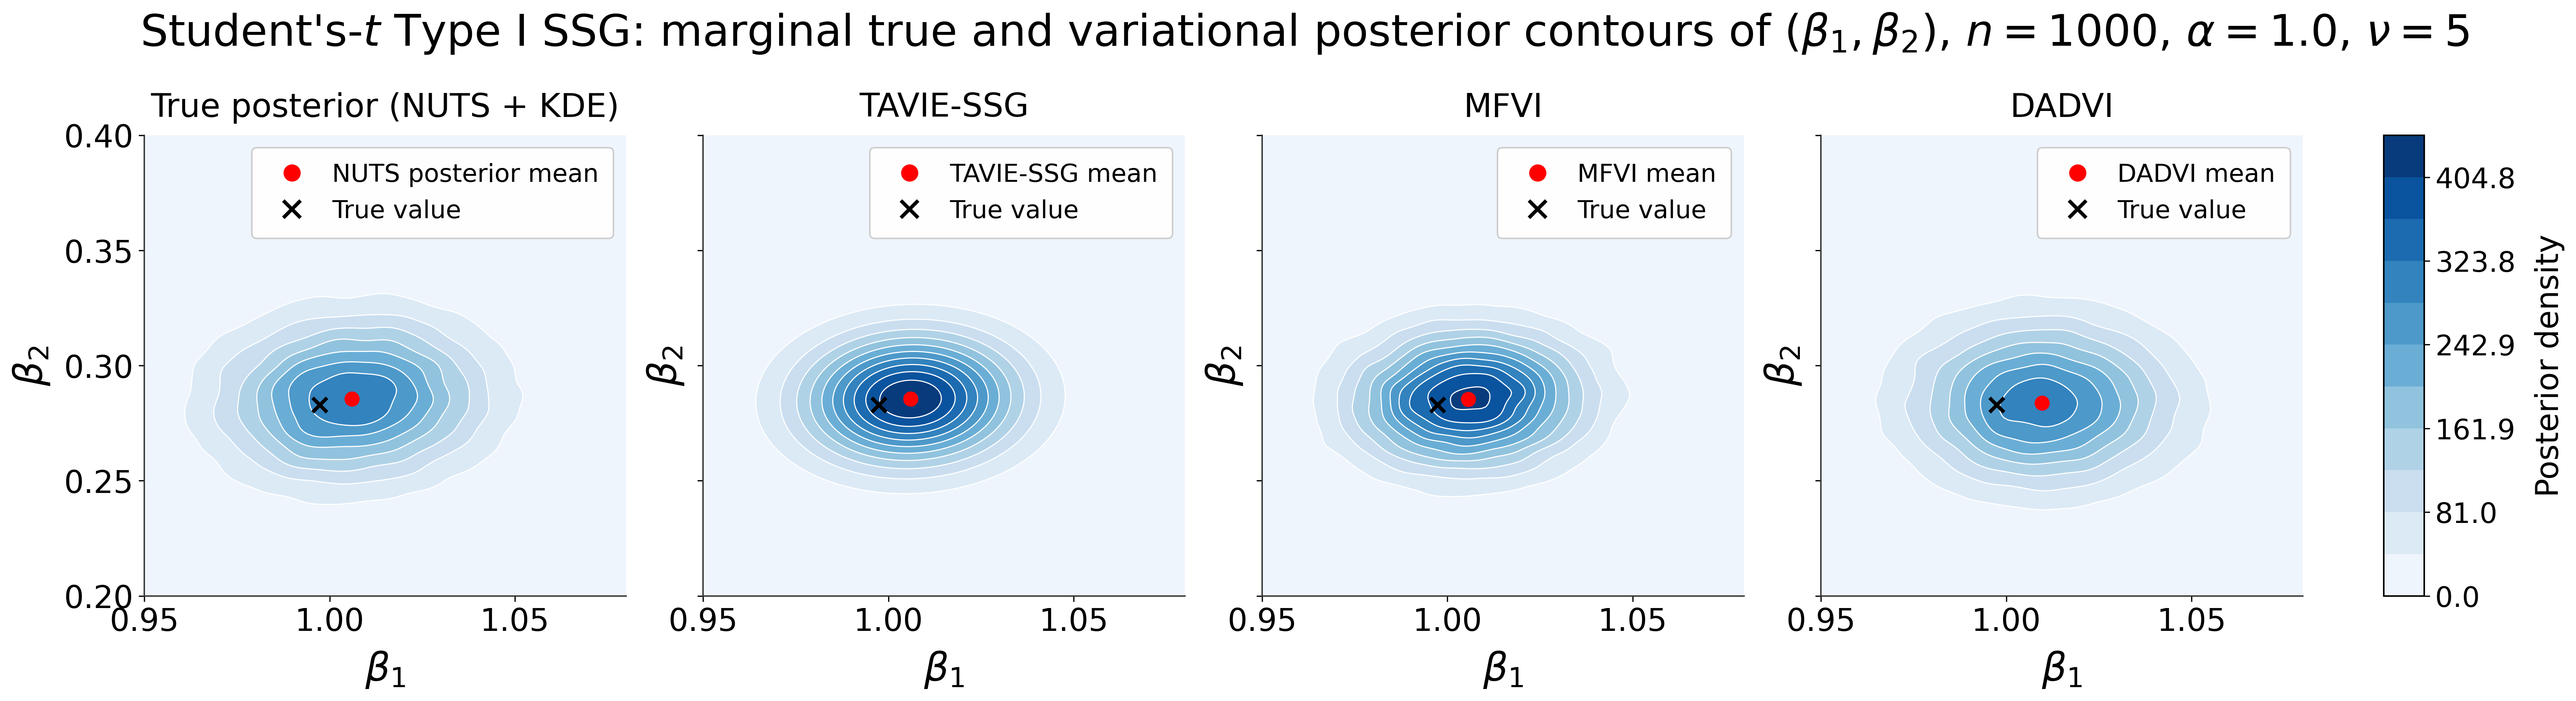

Saved: results_gaps/contour_plots/student_side_by_side_all_methods_n_1000_alpha_1.00_replot.pdf


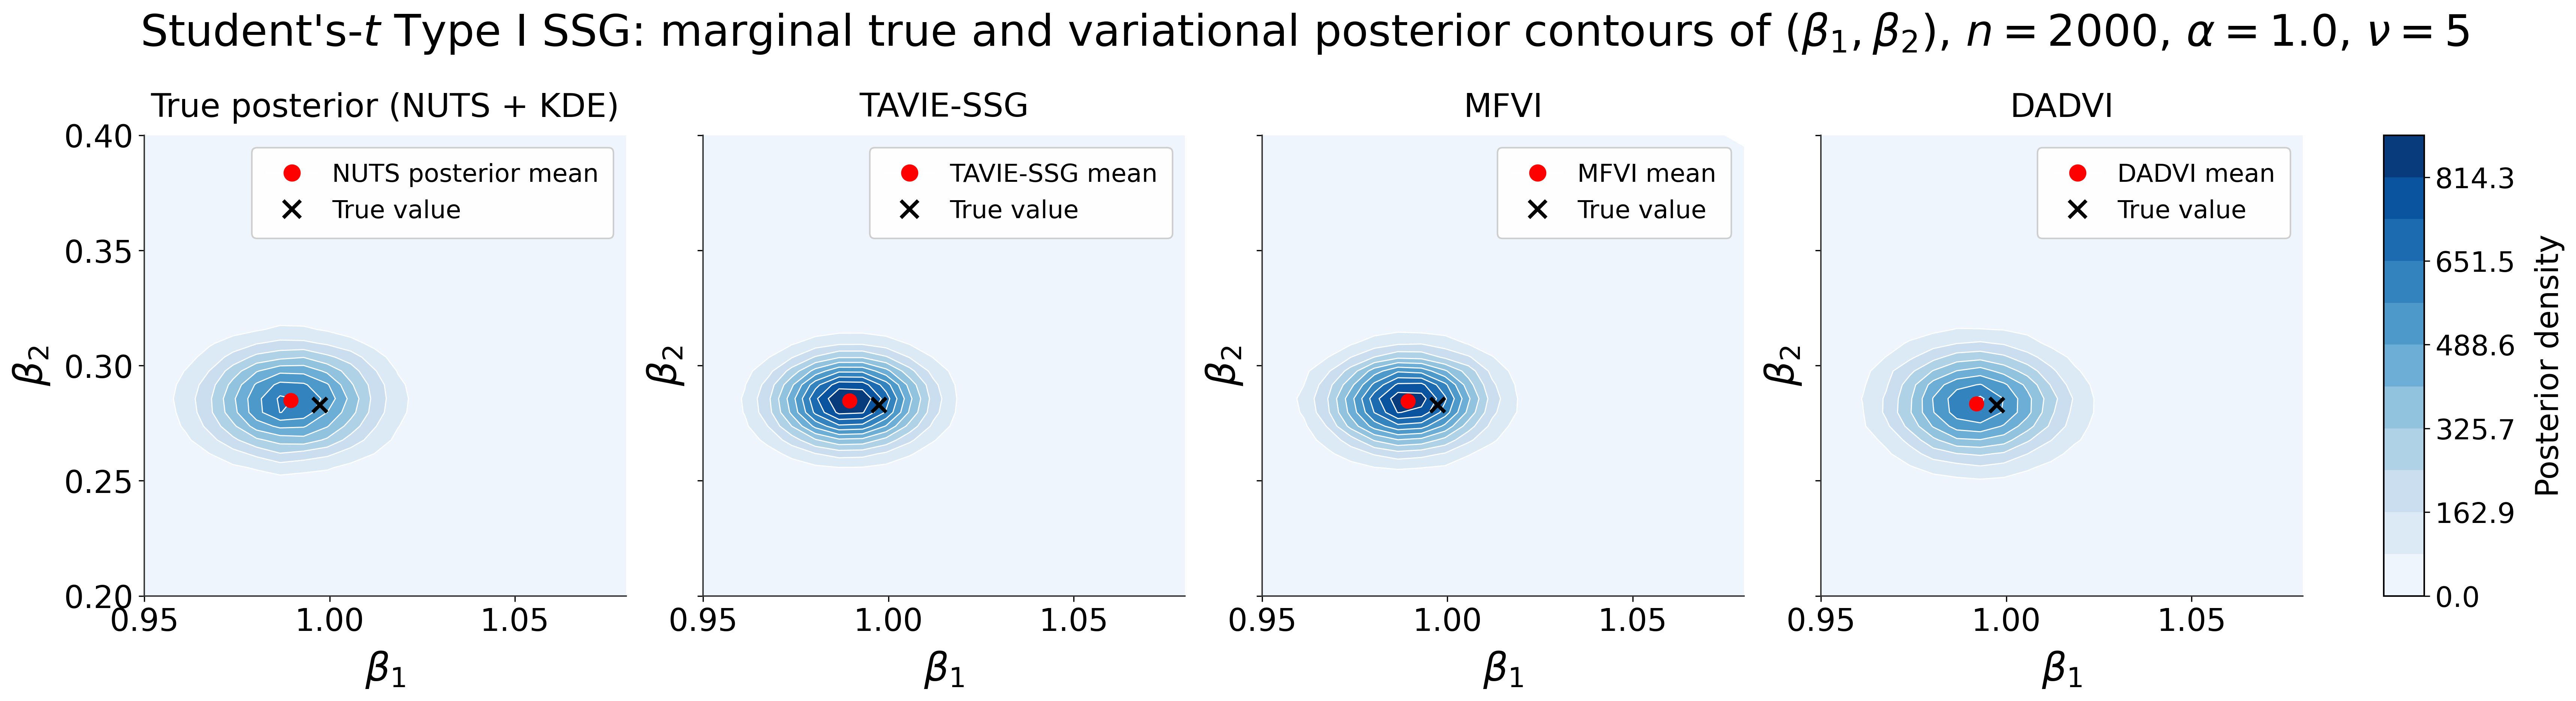

Saved: results_gaps/contour_plots/student_side_by_side_all_methods_n_2000_alpha_1.00_replot.pdf


In [53]:
# ============================================================
# SEPARATE PLOTTING CODE
# Reads saved results and recreates contour plots
# with optional xlim / ylim control
# ============================================================

import os
import pickle

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

output_dir = "results_gaps/contour_plots"
alpha = 1.0

n_values_to_plot = [
    1000,
    2000,
]

panel_order = [
    "True posterior (NUTS + KDE)",
    "TAVIE-SSG",
    "MFVI",
    "DADVI",
    "ADVI (MF)",
    "ADVI (FR)",
]

common_cmap = "Blues"

# Increased height to accommodate the larger text
figsize = (24, 6.5)

# Set these to None for automatic limits
# custom_xlim = None
# custom_ylim = None

custom_xlim = (0.95, 1.08)
custom_ylim = (0.2, 0.4)


# ============================================================
# FONT-SIZE SETTINGS
# ============================================================

MAIN_TITLE_FONTSIZE = 28
PANEL_TITLE_FONTSIZE = 21
AXIS_LABEL_FONTSIZE = 25
TICK_LABEL_FONTSIZE = 20
LEGEND_FONTSIZE = 16
COLORBAR_LABEL_FONTSIZE = 20
COLORBAR_TICK_FONTSIZE = 18


# ============================================================
# LEGEND HANDLES
# ============================================================

def make_legend_handles(mean_label):
    return [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="white",
            markerfacecolor="red",
            markeredgecolor="red",
            markersize=10,
            label=mean_label,
        ),
        plt.Line2D(
            [0],
            [0],
            marker="x",
            color="black",
            linewidth=0,
            markeredgewidth=2.3,
            markersize=11,
            label="True value",
        ),
    ]


# ============================================================
# BUILD PANEL DICTIONARY FROM SAVED OBJECT
# ============================================================

def build_panels_from_result(res):
    return {
        "True posterior (NUTS + KDE)": {
            "Z": res["Z_true"],
            "mean": res["mean_true_2d"],
            "legend_handles": make_legend_handles(
                "NUTS posterior mean"
            ),
        },
        "TAVIE-SSG": {
            "Z": res["Z_tavie"],
            "mean": res["mu_tavie_2d"],
            "legend_handles": make_legend_handles(
                "TAVIE-SSG mean"
            ),
        },
        "MFVI": {
            "Z": res["Z_mfvi"],
            "mean": res["mean_mfvi_2d"],
            "legend_handles": make_legend_handles(
                "MFVI mean"
            ),
        },
        "DADVI": {
            "Z": res["Z_dadvi"],
            "mean": res["mean_dadvi_2d"],
            "legend_handles": make_legend_handles(
                "DADVI mean"
            ),
        },

        # Uncomment these panels if the corresponding arrays
        # are available in the saved results.
        #
        # "ADVI (MF)": {
        #     "Z": res["Z_advi_mf"],
        #     "mean": res["mean_advi_mf_2d"],
        #     "legend_handles": make_legend_handles(
        #         "ADVI MF mean"
        #     ),
        # },
        #
        # "ADVI (FR)": {
        #     "Z": res["Z_advi_fr"],
        #     "mean": res["mean_advi_fr_2d"],
        #     "legend_handles": make_legend_handles(
        #         "ADVI FR mean"
        #     ),
        # },
    }


# ============================================================
# PLOT ONE SAVED RESULT
# ============================================================

def plot_saved_result(
    res,
    save_path=None,
    panel_order=None,
    cmap="Blues",
    figsize=(24, 6.5),
    xlim=None,
    ylim=None,
    show=True,
):
    if panel_order is None:
        panel_order = [
            "True posterior (NUTS + KDE)",
            "TAVIE-SSG",
            "MFVI",
            "DADVI",
        ]

    x_grid = np.asarray(
        res["x_grid"]
    )

    y_grid = np.asarray(
        res["y_grid"]
    )

    XX, YY = np.meshgrid(
        x_grid,
        y_grid,
    )

    beta_idx1 = res["beta_idx1"]
    beta_idx2 = res["beta_idx2"]

    true_x, true_y = res["true_value_2d"]

    levels_common = np.asarray(
        res["levels_common"]
    )

    panels = build_panels_from_result(
        res
    )

    # Keep only panels present in the saved results
    active_panel_order = [
        name
        for name in panel_order
        if name in panels
    ]

    n_panels = len(active_panel_order)

    fig, axes = plt.subplots(
        1,
        n_panels,
        figsize=figsize,
        sharex=True,
        sharey=True,
        facecolor="white",
    )

    axes = np.atleast_1d(
        axes
    ).ravel()

    contour_reference = None

    for ax, name in zip(
        axes,
        active_panel_order,
    ):
        item = panels[name]

        Z = item["Z"]
        mean_point = item["mean"]
        legend_handles = item["legend_handles"]

        filled_contour = ax.contourf(
            XX,
            YY,
            Z,
            levels=levels_common,
            cmap=cmap,
        )

        ax.contour(
            XX,
            YY,
            Z,
            levels=levels_common,
            colors="white",
            linewidths=0.7,
        )

        if contour_reference is None:
            contour_reference = filled_contour

        # Posterior mean
        ax.scatter(
            mean_point[0],
            mean_point[1],
            color="red",
            marker="o",
            s=75,
            zorder=3,
        )

        # True parameter value
        ax.scatter(
            true_x,
            true_y,
            color="black",
            marker="x",
            s=85,
            linewidths=2.3,
            zorder=3,
        )

        # Increased panel-title size
        ax.set_title(
            name,
            fontsize=PANEL_TITLE_FONTSIZE,
            pad=12,
        )

        # Increased x-axis-label size
        ax.set_xlabel(
            rf"$\beta_{{{beta_idx1}}}$",
            fontsize=AXIS_LABEL_FONTSIZE,
            labelpad=8,
        )

        # Increased y-axis-label size
        ax.set_ylabel(
            rf"$\beta_{{{beta_idx2}}}$",
            fontsize=AXIS_LABEL_FONTSIZE,
            labelpad=8,
        )

        # Increased tick-label sizes
        ax.tick_params(
            axis="both",
            labelsize=TICK_LABEL_FONTSIZE,
        )

        # Increased legend size
        ax.legend(
            handles=legend_handles,
            loc="upper right",
            frameon=True,
            framealpha=0.95,
            fontsize=LEGEND_FONTSIZE,
            borderpad=0.6,
            labelspacing=0.5,
            handletextpad=0.6,
        )

        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_color("#333333")
            spine.set_linewidth(0.9)

        if xlim is not None:
            ax.set_xlim(
                xlim
            )

        if ylim is not None:
            ax.set_ylim(
                ylim
            )

    # Increased main-title size
    fig.suptitle(
        r"Student's-$t$ Type I SSG: marginal true and "
        r"variational posterior contours of "
        r"$(\beta_1,\beta_2)$, "
        rf"$n={res['n']}$, "
        rf"$\alpha={res['alpha']}$, "
        rf"$\nu={res['df']}$",
        fontsize=MAIN_TITLE_FONTSIZE,
        y=0.97,
    )

    # Reserve room for the larger main title and labels
    fig.subplots_adjust(
        left=0.07,
        right=0.87,
        top=0.80,
        bottom=0.17,
        wspace=0.16,
    )

    # Colorbar
    colorbar_axis = fig.add_axes([
        0.90,
        0.17,
        0.015,
        0.63,
    ])

    colorbar = fig.colorbar(
        contour_reference,
        cax=colorbar_axis,
    )

    colorbar.set_label(
        "Posterior density",
        fontsize=COLORBAR_LABEL_FONTSIZE,
        labelpad=12,
    )

    colorbar.ax.tick_params(
        labelsize=COLORBAR_TICK_FONTSIZE,
    )

    if save_path is not None:
        fig.savefig(
            save_path,
            format="pdf",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# READ ALL RESULTS
# ============================================================

all_results_path = os.path.join(
    output_dir,
    f"all_results_student_alpha_{alpha:.2f}.pkl",
)

with open(
    all_results_path,
    "rb",
) as file:
    all_results = pickle.load(
        file
    )

print(
    "Loaded saved results from:",
    all_results_path,
)


# ============================================================
# PLOT SELECTED n VALUES
# ============================================================

for n_value in n_values_to_plot:
    result = all_results[n_value]

    figure_path = os.path.join(
        output_dir,
        (
            "student_side_by_side_all_methods_"
            f"n_{n_value}_alpha_{alpha:.2f}_replot.pdf"
        ),
    )

    plot_saved_result(
        res=result,
        save_path=figure_path,
        panel_order=panel_order,
        cmap=common_cmap,
        figsize=figsize,
        xlim=custom_xlim,
        ylim=custom_ylim,
        show=True,
    )

    print(
        "Saved:",
        figure_path,
    )